# Cross-Model Forecast Comparison: Dutch Quarterly Sick Leave (h=4)

This notebook compares five forecasting configurations on the task of predicting sick-leave rates by economic sector, **4 quarters ahead** (matching the business-owner's annual planning horizon):

| Method | Type | Paradigm | Selection |
|---|---|---|---|
| **Pipeline** | Multivariate ML (Ridge / ElasticNet / PLS / HistGBR) | Features encode regime + macro context | Per-sector best variant by mean MAE |
| **AutoETS** | Univariate state-space | Classical statistical | Per-sector best (ETS spec × COVID correction) via inner CV |
| **STL+ETS** | Univariate decomposition | Classical statistical | Per-sector best (STL × ETS × COVID correction) via inner CV |
| **Chronos-Bolt** | Univariate foundation model | Zero-shot transformer | None — predicts directly, no COVID correction |
| **Chronos-Bolt (corr.)** | Univariate foundation model | Foundation model + selection | Per-sector best COVID correction via inner CV |

For each method, the per-sector winning configuration has already been selected. **This notebook compares those per-sector winners against each other.**

### Why two forms of Chronos?

A fair comparison must give every method the same affordances. AutoETS and STL+ETS each *select* a COVID-correction variant per sector on inner folds; the out-of-the-box Chronos forecast does not. So we show **both**:

- **Chronos-Bolt** (zero-shot): the honest "out of the box" data point — what you get with no tuning.
- **Chronos-Bolt (corr.)**: the like-for-like comparator — Chronos given the *same* per-sector COVID-correction selection the ETS methods receive, chosen on inner folds only (no look-ahead).

The correction is applied to the model's *context* only; actuals are always the original, uncorrected series, and the MASE denominator (below) is computed once from the shared baseline — so a correction can move a method's own error but never the shared yardstick.

## Three metrics, three questions

This notebook deliberately uses a small metric set to keep the comparison interpretable:

- **MAE** (in percentage points): how far off, on average, in the same units as the target. The primary stakeholder metric.
- **MASE**: each method's MAE divided by the **`SectorQuarterRollingMean` baseline's MAE** — the deployed operational model (a rolling 3-year same-quarter mean per SBI sector, no look-ahead). The baseline MAE is measured on the **exact same** aligned `(sector, target_date, horizon)` points each method is scored on, so the ratio is strictly like-for-like. (The baseline's per-row walk-forward predictions are read straight from `model_predictions` — the same pipeline step that evaluates every other model writes them there under `SectorQuarterRollingMean_<sector>`, with `sector_code` and `fold_set` columns — and the loaded outer-fold rows are reconciled against the stored aggregate MAE.) Dimensionless and **comparable across sectors** of different difficulty. **MASE < 1 means the method beats the operational baseline.** (Strictly this is a *relative MAE* against an operational baseline rather than the textbook in-sample-naive MASE; we anchor to `SectorQuarterRollingMean` because it is what UWV actually deploys, making "MASE < 1" directly decision-relevant.)
- **Bias** (signed mean error): whether the model systematically over- or under-predicts. Critical diagnostic for workforce planning.

Other common metrics (RMSE, MAPE, sMAPE, R-squared) are deliberately omitted — they either duplicate the signal MAE provides or mislead in non-stationary settings. MAPE is asymmetric and undefined at zero; sMAPE has a counter-intuitive bounded scale; R-squared is explicitly discouraged for non-stationary time series (Hyndman & Athanasopoulos, *Forecasting: Principles and Practice*, sec. 5.8).

## Structure

1. Loading + alignment
2. The three-metric suite
3. **Within-method rankings** — for each method, where does it shine vs struggle?
4. **Cross-method comparison** — sector-by-sector, which method wins?
5. **The quadrant** — univariate vs multivariate × explainable vs black-box, with each sector plotted on its winning method
6. Per-horizon decay & regime split (pre-COVID / COVID / post-recovery)
7. Statistical significance (Friedman + Diebold-Mariano)
8. Sensitivity: gold-imputed vs real-data-only inputs
9. Final winners table + summary

In [2]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Consistent "business-report" styling applied to every figure ───────────
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "savefig.bbox": "tight",
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "legend.fontsize": 9,
    "axes.edgecolor": "#cccccc", "axes.linewidth": 0.8,
    "grid.color": "#e6e6e6", "grid.linewidth": 0.6,
    "xtick.color": "#444444", "ytick.color": "#444444",
    "axes.titlecolor": "#222222", "figure.titleweight": "bold",
})

# ── Consistent palette across ALL charts ───────────────────────────────────
# Two forms of Chronos-Bolt are shown throughout (see the intro note):
#   Chronos_Bolt            zero-shot, no COVID correction  ("out of the box")
#   Chronos_Bolt_corrected  per-sector correction selected on inner folds,
#                           the like-for-like comparator to AutoETS/STL+ETS,
#                           which also select a COVID correction.
METHOD_COLORS = {
    "Pipeline":               "#2E86AB",
    "AutoETS":                "#A23B72",
    "STL_ETS":                "#F18F01",
    "Chronos_Bolt":           "#6A994E",
    "Chronos_Bolt_corrected": "#2D5A27",
}
METHOD_LABELS = {
    "Pipeline":               "Pipeline",
    "AutoETS":                "AutoETS",
    "STL_ETS":                "STL+ETS",
    "Chronos_Bolt":           "Chronos-Bolt",
    "Chronos_Bolt_corrected": "Chronos-Bolt (corr.)",
}
METHOD_ORDER = ["Pipeline", "AutoETS", "STL_ETS",
                "Chronos_Bolt", "Chronos_Bolt_corrected"]
# Reverse map (label -> internal key); used by charts that group on the label.
METHOD_LABELS_INVERSE = {v: k for k, v in METHOD_LABELS.items()}

BASELINE_KEY   = "Baseline"
BASELINE_COLOR = "#999999"     # neutral grey for seasonal-naive / baseline

# Standard footer stamped on every figure for a consistent report look.
SOURCE_NOTE = ("Source: nested walk-forward CV (h=4) · gold-imputed inputs · "
               "MASE vs SectorQuarterRollingMean baseline (point-aligned)")

def add_source_note(fig, text=SOURCE_NOTE):
    """Stamp a small, consistent source line in the lower-right of a figure."""
    fig.text(0.995, 0.005, text, ha="right", va="bottom",
             fontsize=7.5, style="italic", color="#9aa0a6")

# Paths (relative to notebook location: notebooks/ml_experimentation/)
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent             # C:/Git/eaisi-uwv
CV_OUTPUT    = NOTEBOOK_DIR / "cv_output"             # parquets from the CV scripts
EVAL_DB      = PROJECT_ROOT / "data" / "4_eval" / "eval_data.db"

# Make project modules importable
for p in (NOTEBOOK_DIR, PROJECT_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

# Quarter-formatting helper (Python's strftime has no %Q for quarter)
def fmt_quarter(d):
    return f"{d.year}-Q{(d.month - 1) // 3 + 1}"

print("Setup complete.")
print(f"  Notebook dir: {NOTEBOOK_DIR}")
print(f"  CV output:    {CV_OUTPUT}")
print(f"  Eval DB:      {EVAL_DB}")
print(f"  EVAL_DB exists: {EVAL_DB.exists()}")
print(f"  CV_OUTPUT exists: {CV_OUTPUT.exists()}")
print(f"  Methods tracked: {[METHOD_LABELS[m] for m in METHOD_ORDER]}")

Setup complete.
  Notebook dir: c:\Git\eaisi-uwv\notebooks\ml_experimentation
  CV output:    c:\Git\eaisi-uwv\notebooks\ml_experimentation\cv_output
  Eval DB:      c:\Git\eaisi-uwv\data\4_eval\eval_data.db
  EVAL_DB exists: True
  CV_OUTPUT exists: True
  Methods tracked: ['Pipeline', 'AutoETS', 'STL+ETS', 'Chronos-Bolt', 'Chronos-Bolt (corr.)']


## 1. Loading Predictions

Each method's outputs are stored in canonical schema: one row per `(model_name, sector_code, target_date, horizon)`, with `y_true` and `y_pred` plus optional prediction-interval columns.

The Pipeline loader picks the **winning variant per sector** (the model with lowest mean MAE across that sector's predictions) and emits family-level `model_name = "Pipeline"`. The per-sector winning *variant* (Ridge / ElasticNet / PLS / HistGBR) is preserved separately in `pipeline_winners` for the quadrant visualization later.


In [3]:
from src.utils.evaluation_method import (
    load_autoets_predictions, load_stl_ets_predictions, load_chronos_predictions,
    align_predictions, friedman_nemenyi, pairwise_dm_matrix,
)
from src.utils.m_pipeline_loader import load_pipeline_honest

pipeline, pipeline_winners = load_pipeline_honest(EVAL_DB)
autoets  = load_autoets_predictions(CV_OUTPUT / "autoets_predictions.parquet")
stl_ets  = load_stl_ets_predictions(CV_OUTPUT / "stl_ets_predictions.parquet")
chronos  = load_chronos_predictions(CV_OUTPUT / "chronos_predictions.parquet")

# Corrected Chronos is optional: it only exists once run_chronos_cv.py has been
# run (it exports chronos_predictions_corrected.parquet alongside the zero-shot
# file).  Load it if present so every downstream chart can show both forms; the
# whole notebook degrades gracefully to 4 methods if the file is absent.
_chronos_corr_path = CV_OUTPUT / "chronos_predictions_corrected.parquet"
if _chronos_corr_path.exists():
    chronos_corrected = load_chronos_predictions(_chronos_corr_path)
    # Guarantee the model_name column carries the corrected label even if the
    # loader normalises it (the parquet is written with "Chronos_Bolt_corrected").
    chronos_corrected["model_name"] = "Chronos_Bolt_corrected"
    print(f"✓ Corrected Chronos loaded ({len(chronos_corrected):,} rows)")
else:
    chronos_corrected = None
    print("• chronos_predictions_corrected.parquet not found — "
          "showing zero-shot Chronos only (run run_chronos_cv.py to add it).")

# Methods actually loaded, in canonical order.
LOADED = {
    "Pipeline":               pipeline,
    "AutoETS":                autoets,
    "STL_ETS":                stl_ets,
    "Chronos_Bolt":           chronos,
    "Chronos_Bolt_corrected": chronos_corrected,
}
LOADED = {k: v for k, v in LOADED.items() if v is not None}

# Per-method coverage summary (dynamic over whatever loaded)
summary_rows = []
for name, df in LOADED.items():
    summary_rows.append({
        "method": METHOD_LABELS[name],
        "rows": len(df),
        "sectors": df["sector_code"].nunique(),
        "horizons": str(sorted(df["horizon"].unique())),
        "date_range": f"{fmt_quarter(df['target_date'].min())} -> {fmt_quarter(df['target_date'].max())}",
    })
pd.DataFrame(summary_rows).set_index("method")

  [pipeline_loader] Excluded 800 baseline rows (39 model_names matching 'SectorQuarterRollingMean*')
  [pipeline_loader] per_sector_honest: picking variant per sector by INNER-fold MAE (5,320 inner rows across 665 distinct variants)
✓ Corrected Chronos loaded (3,120 rows)


,rows,sectors,horizons,date_range
method,,,,
Pipeline,468,39,"[np.int64(1), np.int64(2), np.int64(3), np.int...",2022-Q4 -> 2025-Q3
AutoETS,3120,39,"[np.int64(1), np.int64(2), np.int64(3), np.int...",2020-Q1 -> 2025-Q3
STL+ETS,9984,39,"[np.int64(1), np.int64(2), np.int64(3), np.int...",2009-Q1 -> 2025-Q3
Chronos-Bolt,3120,39,"[np.int64(1), np.int64(2), np.int64(3), np.int...",2020-Q1 -> 2025-Q3
Chronos-Bolt (corr.),3120,39,"[np.int64(1), np.int64(2), np.int64(3), np.int...",2020-Q1 -> 2025-Q3


In [4]:
# Pipeline's winning variant distribution across sectors.
# Sanity check: under the new "global" mode in m_pipeline_loader, ALL sectors
# should share the same winning_variant.  Under the legacy "per_sector" mode
# (test-set biased), the distribution would show several variants.  Also verify
# that no SectorQuarterRollingMean_* (baseline) names slipped in — those would
# indicate exclude_baseline=True isn't working.

print("Pipeline winning variants across sectors:")
print(pipeline_winners["winning_variant"].value_counts().to_string())
print(f"\nTotal sectors with a Pipeline winner: {len(pipeline_winners)}")

# Baseline-leak diagnostic
_baseline_pattern = "SectorQuarterRollingMean"
leak_count = pipeline_winners["winning_variant"].astype(str).str.startswith(_baseline_pattern).sum()
if leak_count > 0:
    print(f"\n⚠⚠ WARNING: {leak_count} sectors have a baseline model as their "
          f"Pipeline winner. This means baseline predictions are leaking into "
          f"the 'Pipeline' column.  Re-load with exclude_baseline=True (default).")
else:
    print(f"\n✓ No baseline names in Pipeline winners (good — no leak).")

Pipeline winning variants across sectors:
winning_variant
PLS_Reduced_300003            1
Ridge_Reduced_300007          1
ElasticNet_Reduced_300013     1
AutoETS_Stat_301000           1
ElasticNet_Reduced_305700     1
Ridge_Reduced_307500          1
PLS_Reduced_307610            1
Ridge_Reduced_317105          1
PLS_Reduced_320005            1
PLS_Reduced_328110            1
PLS_Reduced_346600            1
ElasticNet_Reduced_348000     1
Ridge_Reduced_350000          1
ElasticNet_Reduced_354200     1
PLS_Reduced_354300            1
ElasticNet_Reduced_356900     1
AutoETS_Stat_371600           1
PLS_Reduced_383100            1
PLS_Reduced_383200            1
AutoETS_Stat_389100           1
Ridge_Reduced_391600          1
HistGBR_Reduced_396300        1
Ridge_Reduced_402000          1
HistGBR_Reduced_403300        1
PLS_Reduced_410200            1
AutoETS_Stat_415300           1
ElasticNet_Reduced_417400     1
PLS_Reduced_419000            1
ElasticNet_Reduced_422400     1
PLS_Reduced_42

In [5]:
# Load the SectorQuarterRollingMean BASELINE (per-row), SBI sector titles, and
# per-method best-config settings.
#
# The deployed baseline is evaluated by the same pipeline step as every other
# model (ml_5 ModelEvaluator.evaluate → model_predictions), so its PER-ROW
# walk-forward predictions are already in the eval DB.  The orchestrator's
# `{family}_{sector}` naming convention stores them under model_name
# "SectorQuarterRollingMean_<sector>" (NOT the flat name), with the sector_code
# and fold_set columns populated.  We read those outer-fold rows directly — no
# reconstruction needed — and keep the aggregate MAE only as a reconciliation
# reference / last-resort fallback.

import sqlite3
import json as _json
import warnings as _w
from sqlalchemy import create_engine as _ce, inspect as _sa_inspect

_engine = _ce(f"sqlite:///{EVAL_DB.as_posix()}")
_tables = set(_sa_inspect(_engine).get_table_names())
_BASELINE_FAMILY = "SectorQuarterRollingMean"   # config.name; rows are <family>_<sector>


def _baseline_preds_from_db():
    """Per-row baseline predictions from model_predictions, matching the
    family on the model_name prefix and keeping the honest outer folds."""
    if "model_predictions" not in _tables:
        return None
    cols = {c["name"] for c in _sa_inspect(_engine).get_columns("model_predictions")}
    needed = {"sector_code", "target_date", "y_true", "y_pred", "model_name"}
    if not needed <= cols:
        return None
    select = ["sector_code", "target_date", "y_true", "y_pred", "model_name"]
    if "horizon" in cols:
        select.append("horizon")
    if "fold_set" in cols:
        select.append("fold_set")
    # LIKE '<family>%' then exact-prefix filter in pandas (avoids '_' wildcard issues)
    df = pd.read_sql(
        f'SELECT {", ".join(select)} FROM model_predictions '
        f"WHERE model_name LIKE '{_BASELINE_FAMILY}%'", _engine)
    if df.empty:
        return None
    keep = (df["model_name"] == _BASELINE_FAMILY) | \
           df["model_name"].str.startswith(_BASELINE_FAMILY + "_")
    df = df[keep].copy()
    if df.empty:
        return None
    df["sector_code"] = df["sector_code"].astype(str)
    df["target_date"] = pd.to_datetime(df["target_date"])
    # Honest out-of-sample: keep outer folds when the label exists.
    if "fold_set" in df.columns and (df["fold_set"] == "outer").any():
        df = df[df["fold_set"] == "outer"].copy()
    return df.drop(columns=["model_name"])


def _baseline_mae_aggregate():
    """Aggregate outer-fold MAE per 'SectorQuarterRollingMean_<code>' from
    model_evaluations — used to reconcile the per-row load, and as a fallback."""
    if "model_evaluations" not in _tables:
        return pd.Series(dtype=float)
    cols = {c["name"] for c in _sa_inspect(_engine).get_columns("model_evaluations")}
    if "mae" not in cols or "model_name" not in cols:
        return pd.Series(dtype=float)
    order = "ORDER BY timestamp DESC" if "timestamp" in cols else ""
    df = pd.read_sql(f"SELECT model_name, mae FROM model_evaluations "
                     f"WHERE model_name LIKE '{_BASELINE_FAMILY}\\_%' ESCAPE '\\' {order}",
                     _engine)
    if df.empty:
        df = pd.read_sql(f"SELECT model_name, mae FROM model_evaluations "
                         f"WHERE model_name LIKE '{_BASELINE_FAMILY}%' {order}", _engine)
    if df.empty:
        return pd.Series(dtype=float)
    df = df[df["model_name"].str.startswith(_BASELINE_FAMILY + "_")].copy()
    df["sector_code"] = (df["model_name"]
                         .str.replace(_BASELINE_FAMILY + "_", "", regex=False).astype(str))
    df = df.drop_duplicates(subset=["sector_code"], keep="first")
    return df.set_index("sector_code")["mae"].astype(float)


try:
    baseline_mae_aggregate = _baseline_mae_aggregate()
except Exception:
    baseline_mae_aggregate = pd.Series(dtype=float)

try:
    baseline_preds = _baseline_preds_from_db()
except Exception as _e:                              # noqa: BLE001
    print(f"  (baseline per-row load error: {type(_e).__name__}: {_e})")
    baseline_preds = None

if baseline_preds is not None and not baseline_preds.empty:
    _hz = "with horizon" if "horizon" in baseline_preds.columns else "horizon column absent"
    _fold = "outer-fold" if True else ""
    print(f"✓ Baseline (SectorQuarterRollingMean) loaded PER-ROW from model_predictions "
          f"[{_hz}]: {len(baseline_preds):,} rows, "
          f"{baseline_preds['sector_code'].nunique()} sectors.")
    print(f"  → MASE will be anchored to this baseline, point-aligned in section 3.")
elif not baseline_mae_aggregate.empty:
    print(f"⚠ No per-row baseline rows found under '{_BASELINE_FAMILY}_<sector>' in "
          f"model_predictions; only the aggregate MAE ({len(baseline_mae_aggregate)} "
          f"sectors) is available. MASE will fall back to seasonal-naive in section 3.")
else:
    _w.warn(f"No SectorQuarterRollingMean baseline found. Tables: {sorted(_tables)}")

# ── SBI sector titles from the silver DB ────────────────────────────────────
try:
    from src.config import DIR_DB_SILVER as _DB_SILVER_PATH
except ImportError:
    _DB_SILVER_PATH = PROJECT_ROOT / "data" / "2_silver" / "silver_data.db"

try:
    with sqlite3.connect(str(_DB_SILVER_PATH)) as con:
        titles_df = pd.read_sql(
            'SELECT DISTINCT '
            '  BedrijfskenmerkenSBI2008       AS sector_code, '
            '  BedrijfskenmerkenSBI2008_Title AS title '
            'FROM "80072ned_silver"', con)
    sbi_titles = dict(zip(titles_df["sector_code"].astype(str), titles_df["title"]))
    print(f"✓ SBI titles loaded for {len(sbi_titles)} codes")
except Exception as _e:
    sbi_titles = {}
    print(f"⚠ Could not load SBI titles ({_e}); winners table will show codes only")

# ── Per-method best-config settings for the winners table ───────────────────
def _load_json_maybe(path):
    if not path.exists():
        return {}
    with open(path) as f:
        return _json.load(f)

autoets_settings           = _load_json_maybe(CV_OUTPUT / "autoets_best_configs.json")
stl_ets_settings           = _load_json_maybe(CV_OUTPUT / "stl_ets_best_configs.json")
chronos_corrected_settings = _load_json_maybe(CV_OUTPUT / "chronos_best_configs.json")
pipeline_settings          = dict(zip(pipeline_winners["sector_code"].astype(str),
                                      pipeline_winners["winning_variant"]))
print(f"✓ Best-configs loaded: "
      f"AutoETS={len(autoets_settings)}, "
      f"STL+ETS={len(stl_ets_settings)}, "
      f"Chronos-corr={len(chronos_corrected_settings)}, "
      f"Pipeline={len(pipeline_settings)}")

✓ Baseline (SectorQuarterRollingMean) loaded PER-ROW from model_predictions [with horizon]: 480 rows, 39 sectors.
  → MASE will be anchored to this baseline, point-aligned in section 3.
✓ SBI titles loaded for 39 codes
✓ Best-configs loaded: AutoETS=39, STL+ETS=39, Chronos-corr=39, Pipeline=39


## 2. Aligning Predictions

Models can only be compared on the **intersection** of `(sector, target_date, horizon)` tuples that all four methods predicted. If one method has noticeably fewer rows after alignment, it had narrower coverage - worth noting in the report.


In [6]:
# Align on the intersection of (sector_code, target_date, horizon) across every
# loaded method.  Corrected Chronos shares the exact CV grid of zero-shot
# Chronos, so adding it does not shrink the aligned set.
_model_dfs = [df for df in (pipeline, autoets, stl_ets, chronos, chronos_corrected)
              if df is not None]

aligned, report = align_predictions(_model_dfs)

# Canonical order, restricted to what actually survived alignment.
PRESENT_METHODS = [m for m in METHOD_ORDER
                   if m in set(aligned["model_name"].unique())]

print(f"Aligned rows: {len(aligned):,}")
print(f"Sectors in alignment: {aligned['sector_code'].nunique()}")
print(f"Horizons: {sorted(aligned['horizon'].unique())}")
print(f"Methods present: {[METHOD_LABELS[m] for m in PRESENT_METHODS]}")

print(f"\nAlignment report contents:")
if hasattr(report, 'per_model'):
    for k, v in report.per_model.items():
        print(f"  {METHOD_LABELS.get(k, k)}: {v}")
elif isinstance(report, dict):
    for k, v in report.items():
        print(f"  {k}: {v}")
else:
    print(f"  {report}")

Aligned rows: 2,340
Sectors in alignment: 39
Horizons: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Methods present: ['Pipeline', 'AutoETS', 'STL+ETS', 'Chronos-Bolt', 'Chronos-Bolt (corr.)']

Alignment report contents:
  === Alignment report ===
  intersection key: ('sector_code', 'target_date', 'horizon')
  models aligned:   5
  aligned rows:     2340
  aligned sectors:  39
  aligned horizons: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

  per-model coverage (native → aligned):
    Pipeline                      :    468 →    468  (100.0% retained)
    AutoETS                       :   3120 →    468  (15.0% retained)
    STL_ETS                       :   9984 →    468  (4.7% retained)
    Chronos_Bolt                  :   3120 →    468  (15.0% retained)
    Chronos_Bolt_corrected        :   3120 →    468  (15.0% retained)


## 3. The Three-Metric Suite

| Metric | Units | Reads as | Best for |
|---|---|---|---|
| **MAE** | percentage points | Average absolute deviation in original units | Stakeholder communication |
| **MASE** | dimensionless | <1 beats naive seasonal forecast | Cross-sector comparison; defensibility |
| **Bias** | percentage points | Systematic over (+) or under (-) prediction | Diagnostic for miscalibration |

MASE here uses a **test-set seasonal-naive baseline** (mean of `|y[t] - y[t-4]|` over the available test target dates per sector). The textbook definition uses *in-sample* training data; this practical variant is what we can compute from a predictions-only file. Relative rankings between methods are unchanged; absolute MASE values would shift slightly if using the textbook variant.


In [7]:
def _seasonal_naive_mae(actuals_by_date, season=4):
    """Seasonal-naive MAE with a DATE-AWARE lag (year-ago quarter).
    FALLBACK denominator for when baseline predictions are unavailable."""
    s = actuals_by_date.sort_index()
    s = s[~s.index.duplicated(keep="first")]
    lagged = s.shift(season, freq=pd.offsets.QuarterEnd()).reindex(s.index)
    diff = (s - lagged).abs().dropna()
    return float(diff.mean()) if not diff.empty else np.nan


def _sector_actuals_series(g):
    a = (g[["target_date", "y_true"]]
         .drop_duplicates("target_date")
         .assign(target_date=lambda d: pd.to_datetime(d["target_date"]))
         .set_index("target_date")["y_true"]
         .sort_index())
    return a


def build_naive_baselines(aligned_df, season=4, eps=1e-9):
    baselines = {}
    for sec, g in aligned_df.groupby("sector_code"):
        nm = _seasonal_naive_mae(_sector_actuals_series(g), season)
        if np.isfinite(nm) and nm >= eps:
            baselines[sec] = nm
    return baselines


def aligned_baseline_mae(aligned_df, baseline_preds, eps=1e-9):
    """Per-sector MAE of the SectorQuarterRollingMean baseline, measured on the
    SAME unique aligned (sector, target_date, horizon) points the methods are
    scored on.  Baseline y_pred is merged onto that grid and the error taken
    against the aligned y_true, so numerator and denominator share points and
    actuals.  If the baseline has no horizon column its prediction is broadcast
    across each target's horizons.  Returns ({sector -> MAE}, matched_rows)."""
    if baseline_preds is None or len(baseline_preds) == 0:
        return {}, pd.DataFrame()
    bl = baseline_preds.copy()
    bl["sector_code"] = bl["sector_code"].astype(str)
    bl["target_date"] = pd.to_datetime(bl["target_date"])
    al = aligned_df.copy()
    al["sector_code"] = al["sector_code"].astype(str)
    al["target_date"] = pd.to_datetime(al["target_date"])

    grid = al[["sector_code", "target_date", "horizon", "y_true"]] \
        .drop_duplicates(["sector_code", "target_date", "horizon"])
    mkeys = ["sector_code", "target_date"]
    if "horizon" in bl.columns:
        mkeys = mkeys + ["horizon"]
    blu = bl[mkeys + ["y_pred"]].drop_duplicates(mkeys)
    matched = grid.merge(blu, on=mkeys, how="inner")
    if matched.empty:
        return {}, matched
    matched["abs_err"] = (matched["y_pred"] - matched["y_true"]).abs()
    lookup = (matched.groupby("sector_code")["abs_err"].mean()
              .loc[lambda s: s >= eps].to_dict())
    return lookup, matched


def compute_metrics(df, naive_baseline_lookup=None, season=4, eps=1e-9):
    """MAE, MASE, bias on a (y_true, y_pred) DataFrame.

    MASE = mean over sectors of (sector model-MAE / sector baseline-MAE).  With
    `naive_baseline_lookup` supplied (normal path) the denominator is the
    point-aligned SectorQuarterRollingMean MAE; sectors absent from it are
    skipped so a single consistent denominator is used.  With None, a date-aware
    seasonal-naive denominator is computed on the fly (fallback only)."""
    y_true = df["y_true"].values
    y_pred = df["y_pred"].values
    err    = y_pred - y_true
    mae    = np.abs(err).mean()
    bias   = err.mean()

    mase_vals = []
    for sec, g in df.groupby("sector_code"):
        if naive_baseline_lookup is not None:
            if sec not in naive_baseline_lookup:
                continue
            denom = naive_baseline_lookup[sec]
        else:
            denom = _seasonal_naive_mae(_sector_actuals_series(g), season)
        if not np.isfinite(denom) or denom < eps:
            continue
        sec_mae = np.abs(g["y_true"].values - g["y_pred"].values).mean()
        mase_vals.append(sec_mae / denom)

    return {
        "n":    len(df),
        "MAE":  mae,
        "MASE": float(np.mean(mase_vals)) if mase_vals else np.nan,
        "bias": bias,
    }


# ── MASE denominator: point-aligned SectorQuarterRollingMean MAE ────────────
BASELINE_MAE_ALIGNED, _bl_matched = aligned_baseline_mae(
    aligned, baseline_preds if "baseline_preds" in dir() else None)

if BASELINE_MAE_ALIGNED:
    NAIVE_BASELINES = BASELINE_MAE_ALIGNED          # name kept for downstream cells
    baseline_mae    = pd.Series(BASELINE_MAE_ALIGNED, dtype=float)  # used by winners table
    MASE_BASELINE_NAME = "SectorQuarterRollingMean"
    _npts = _bl_matched.drop_duplicates(["sector_code", "target_date", "horizon"]).shape[0]
    print(f"MASE denominator = SectorQuarterRollingMean (per-row from model_predictions), "
          f"point-aligned: {len(BASELINE_MAE_ALIGNED)} sectors, {_npts:,} points matched.")
    _uncovered = sorted(set(aligned['sector_code'].astype(str)) - set(BASELINE_MAE_ALIGNED))
    if _uncovered:
        print(f"  ⚠ {len(_uncovered)} aligned sector(s) lack baseline predictions and "
              f"are excluded from MASE: {_uncovered}")

    # ── RECONCILIATION: the per-row baseline we loaded should reproduce the
    # aggregate MAE the pipeline stored for the deployed model (both are the
    # baseline's own outer-fold predictions).  Recompute per-sector MAE over the
    # FULL loaded outer rows and compare, with an explicit PASS/FAIL.
    baseline_reconciliation = None
    if "baseline_mae_aggregate" in dir() and not baseline_mae_aggregate.empty:
        _RECON_TOL = 0.01    # 1% per-sector relative tolerance
        _full = baseline_preds.copy()
        _full["sector_code"] = _full["sector_code"].astype(str)
        _full["abs_err"] = (_full["y_pred"] - _full["y_true"]).abs()
        _recomp = _full.groupby("sector_code")["abs_err"].mean()
        baseline_reconciliation = pd.DataFrame({
            "recomputed_per_row": _recomp,
            "stored_aggregate":   baseline_mae_aggregate.astype(float),
        }).dropna()
        br = baseline_reconciliation
        br["rel_diff"] = (br["recomputed_per_row"] - br["stored_aggregate"]).abs() \
            / br["stored_aggregate"].abs().clip(lower=1e-9)
        n_cmp = len(br); n_ok = int((br["rel_diff"] <= _RECON_TOL).sum())
        max_rel = float(br["rel_diff"].max()) if n_cmp else float("nan")
        print(f"\n  ── Per-row vs aggregate baseline reconciliation ──")
        print(f"     sectors compared: {n_cmp} | within {_RECON_TOL:.0%}: {n_ok}/{n_cmp} "
              f"| max rel.diff: {max_rel:.3%}")
        if n_cmp and n_ok == n_cmp:
            print(f"     ✓ PASS — the per-row baseline reproduces the stored aggregate MAE.")
        elif n_cmp:
            worst = br.sort_values("rel_diff", ascending=False).head(6)
            print(f"     ✗ FAIL — {n_cmp - n_ok} sector(s) exceed {_RECON_TOL:.0%}; "
                  f"inspect `baseline_reconciliation`. Likely a fold_set mismatch "
                  f"(per-row filtered to outer vs an aggregate over different folds). Worst:")
            for sec, r in worst.iterrows():
                print(f"        {sec}: per-row={r['recomputed_per_row']:.4f}  "
                      f"stored={r['stored_aggregate']:.4f}  rel.diff={r['rel_diff']:.1%}")
else:
    NAIVE_BASELINES = build_naive_baselines(aligned)
    MASE_BASELINE_NAME = "seasonal-naive (year-ago quarter)"
    print(f"⚠ No point-aligned baseline available — MASE FELL BACK to the "
          f"date-aware seasonal-naive baseline for {len(NAIVE_BASELINES)} sectors.")

# Overall metrics per method
overall_rows = []
for method in PRESENT_METHODS:
    sub = aligned[aligned["model_name"] == method]
    if len(sub) == 0:
        continue
    m = compute_metrics(sub, NAIVE_BASELINES)
    m["method"] = METHOD_LABELS[method]
    overall_rows.append(m)

overall_df = pd.DataFrame(overall_rows).set_index("method")
overall_df = overall_df[["n", "MAE", "MASE", "bias"]]
print(f"(MASE baseline: {MASE_BASELINE_NAME}; MASE < 1 beats it)")
overall_df.round(3)

MASE denominator = SectorQuarterRollingMean (per-row from model_predictions), point-aligned: 39 sectors, 468 points matched.

  ── Per-row vs aggregate baseline reconciliation ──
     sectors compared: 39 | within 1%: 39/39 | max rel.diff: 0.000%
     ✓ PASS — the per-row baseline reproduces the stored aggregate MAE.
(MASE baseline: SectorQuarterRollingMean; MASE < 1 beats it)


,n,MAE,MASE,bias
method,,,,
Pipeline,468,0.496,1.112,-0.082
AutoETS,468,0.269,0.584,-0.091
STL+ETS,468,0.216,0.478,-0.026
Chronos-Bolt,468,0.236,0.520,-0.024
Chronos-Bolt (corr.),468,0.239,0.523,-0.053


### Reading the overall table

- **MAE** (lower better): the average prediction is off by this many percentage points. For sick leave averaging ~5%, an MAE of 0.3 means typical 6% relative error.
- **MASE** (lower better, <1 = better than naive baseline): if MASE = 0.85, the model is 15% better than just predicting "same quarter as last year".
- **bias** (closer to 0 = better): positive means the model over-predicts on average; negative means under-predicts. A model with low MAE but large absolute bias is consistently leaning one way - relevant for capacity planning.


## 4. Per-Sector Metric Matrix

Now we drill into per-sector performance. This is the foundation for the within-method rankings (Section 5) and cross-method comparison (Section 6).


In [28]:
def per_sector_metric_table(aligned_df, naive_baselines):
    rows = []
    for (method, sector), g in aligned_df.groupby(["model_name", "sector_code"]):
        m = compute_metrics(g, naive_baselines)
        m["method"] = method
        m["sector_code"] = sector
        rows.append(m)
    return pd.DataFrame(rows)

per_sector = per_sector_metric_table(aligned, NAIVE_BASELINES)
print(f"Per-sector x method records: {len(per_sector)}")
per_sector.head(10)


Per-sector x method records: 195


,n,MAE,MASE,bias,method,sector_code
0,12,0.190902,0.780961,0.126649,AutoETS,300003
1,12,0.187313,0.654685,-0.130574,AutoETS,300007
2,12,0.226898,0.371288,-0.122186,AutoETS,300013
3,12,0.521013,1.550123,-0.325339,AutoETS,301000
4,12,0.407612,1.222837,-0.220132,AutoETS,305700
5,12,0.176264,0.689727,-0.040051,AutoETS,307500
6,12,0.181364,0.588206,-0.162370,AutoETS,307610
7,12,0.383661,0.600513,-0.251137,AutoETS,317105
8,12,0.225236,0.563089,-0.060466,AutoETS,320005
9,12,0.145880,0.426966,-0.099034,AutoETS,328110


## 5. Within-Method Sector Rankings

For each method, sectors are ranked from best (lowest MAE, top) to worst. The dashed line is the method's median.

We show both **MAE** (absolute, in pp) and **MASE** (scale-free) because they tell different stories:
- MAE ranking shows which sectors are *easy* in absolute terms (often low-variability sectors regardless of model quality)
- MASE ranking shows which sectors the method *adds the most value* on (best below 1, worst above 1)


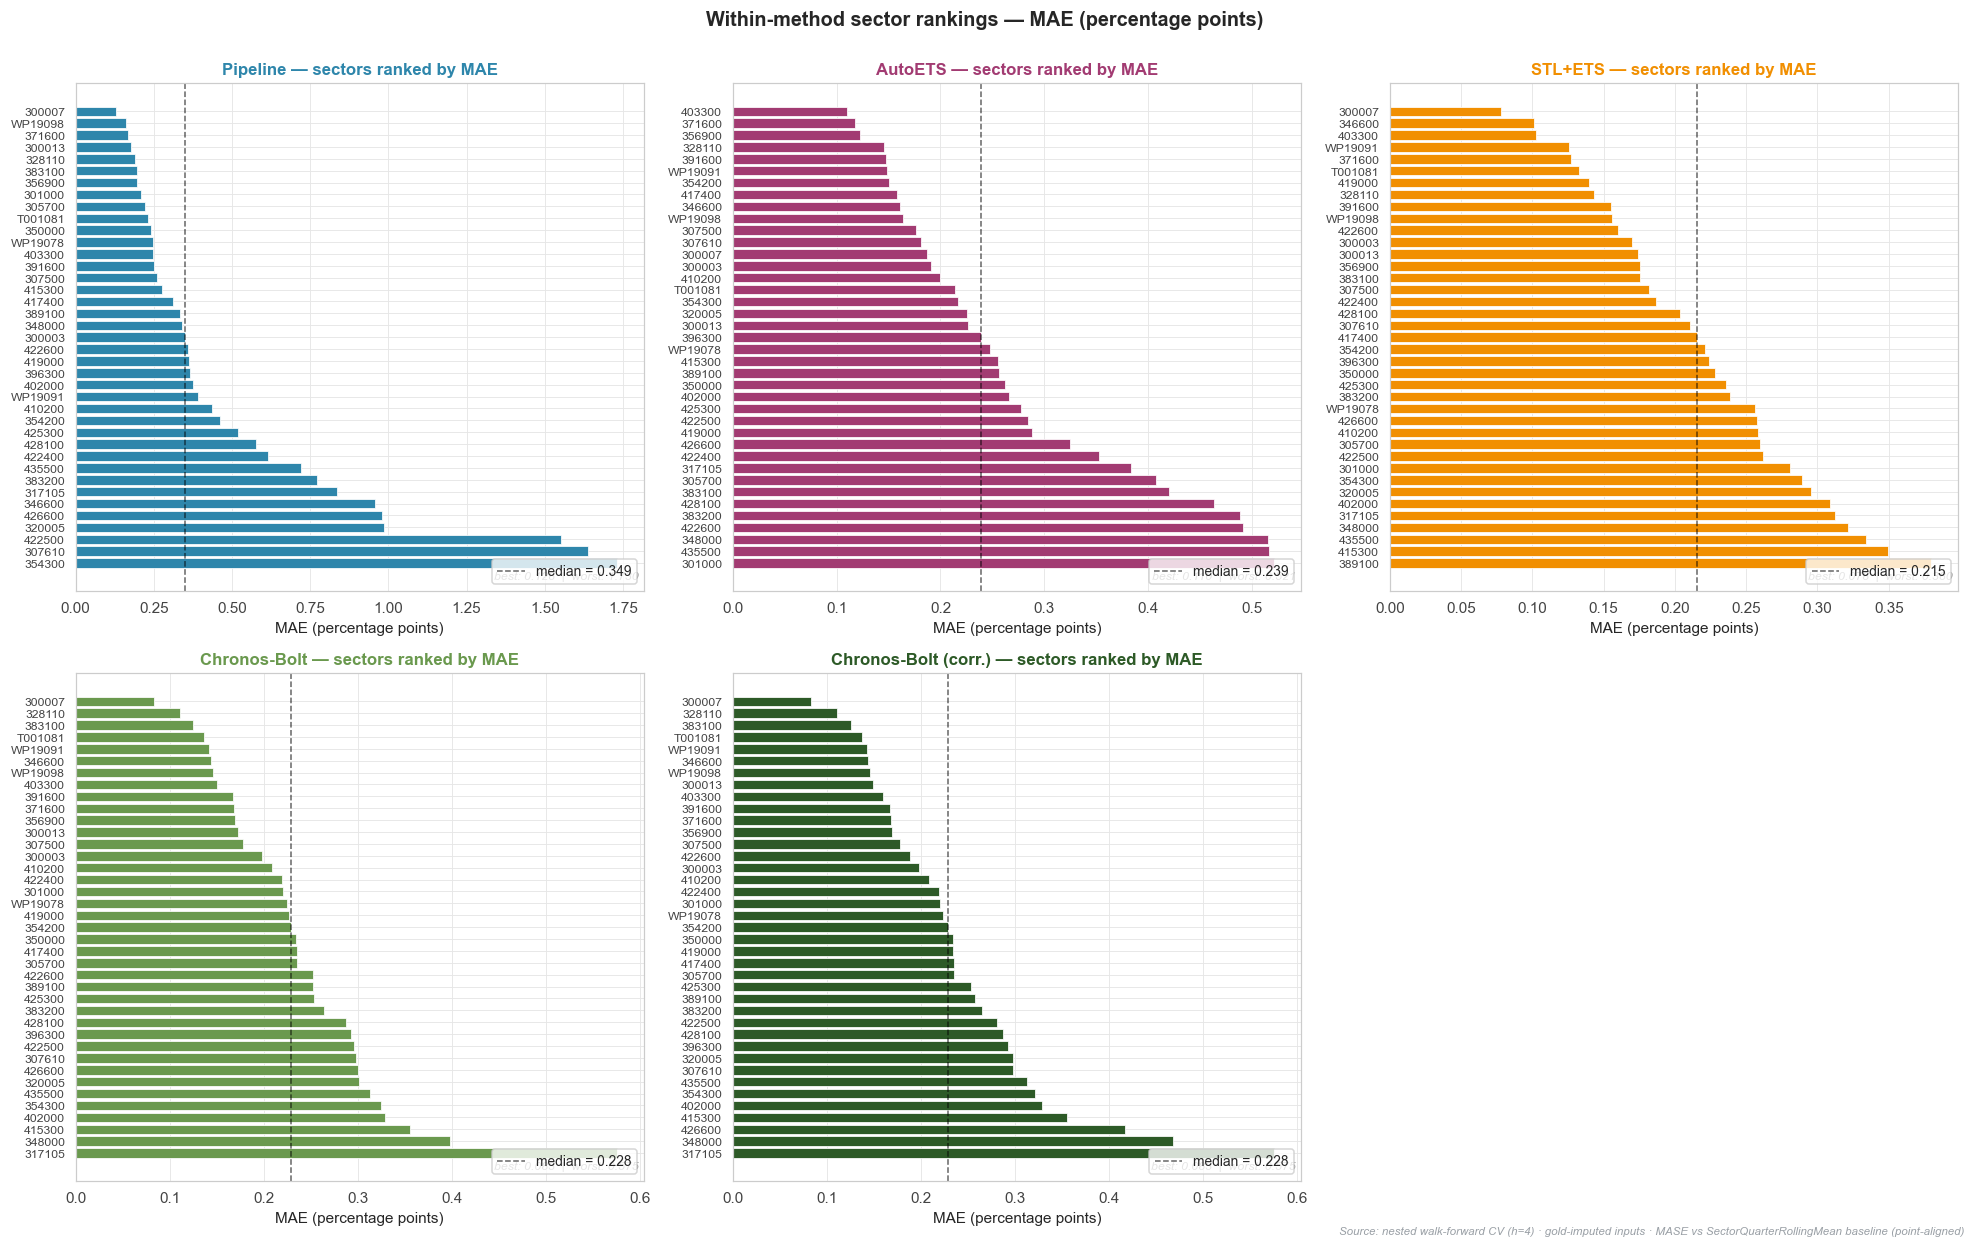

In [9]:
# Within-method sector rankings — MAE.  Dynamic grid so every present method
# gets a panel (a fixed 2x2 would silently drop the 5th method).
import math

_methods = PRESENT_METHODS
_n = len(_methods)
_ncols = min(3, _n)
_nrows = math.ceil(_n / _ncols)

fig, axes = plt.subplots(_nrows, _ncols, figsize=(6.0 * _ncols, 5.6 * _nrows))
axes = np.atleast_1d(axes).flatten()

for ax, method in zip(axes, _methods):
    sub = per_sector[per_sector["method"] == method].copy().sort_values("MAE")
    if sub.empty:
        ax.set_visible(False); continue
    color = METHOD_COLORS[method]
    ax.barh(range(len(sub)), sub["MAE"].values, color=color,
            edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["sector_code"].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("MAE (percentage points)")
    ax.set_title(f"{METHOD_LABELS[method]} — sectors ranked by MAE",
                 fontsize=11, fontweight='bold', color=color)
    median = sub["MAE"].median()
    ax.axvline(median, color="black", linestyle="--", linewidth=1, alpha=0.6,
               label=f"median = {median:.3f}")
    ax.legend(loc="lower right", fontsize=9)
    ax.text(0.99, 0.02,
            f"best: {sub['MAE'].iloc[0]:.3f}  |  worst: {sub['MAE'].iloc[-1]:.3f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, color="gray", style="italic")

for ax in axes[_n:]:
    ax.set_visible(False)

plt.suptitle("Within-method sector rankings — MAE (percentage points)",
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
add_source_note(fig)
plt.show()

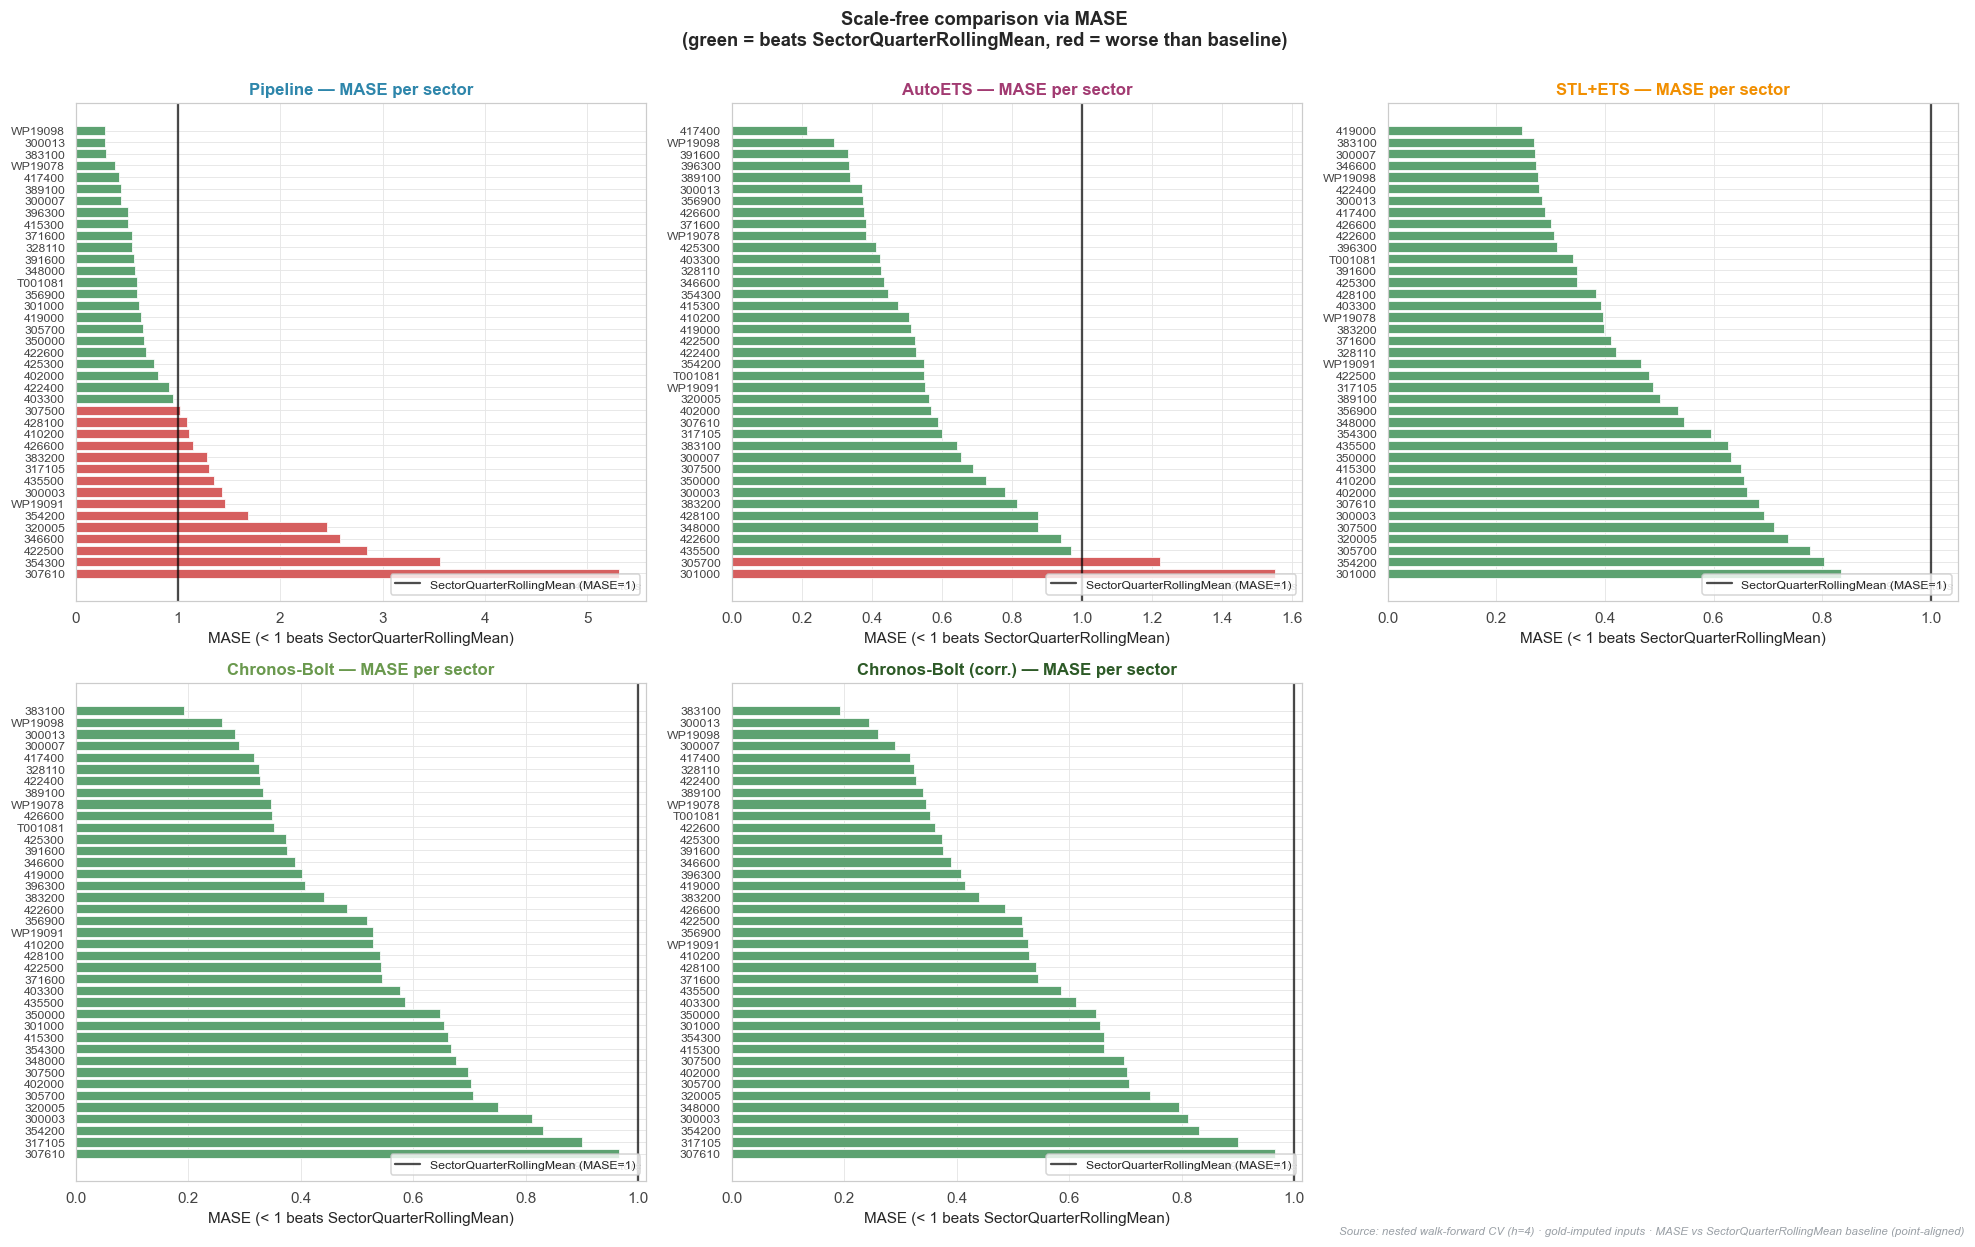

In [35]:
# Within-method sector rankings — MASE.  green bars beat the
# SectorQuarterRollingMean baseline (MASE < 1), red lose.  Dynamic grid, present methods.
import math

_methods = PRESENT_METHODS
_n = len(_methods)
_ncols = min(3, _n)
_nrows = math.ceil(_n / _ncols)

fig, axes = plt.subplots(_nrows, _ncols, figsize=(6.0 * _ncols, 5.6 * _nrows))
axes = np.atleast_1d(axes).flatten()

for ax, method in zip(axes, _methods):
    sub = (per_sector[per_sector["method"] == method]
           .dropna(subset=["MASE"]).sort_values("MASE"))
    if sub.empty:
        ax.set_visible(False); continue
    bar_colors = ["#5DA271" if v < 1.0 else "#D65F5F" for v in sub["MASE"].values]
    ax.barh(range(len(sub)), sub["MASE"].values, color=bar_colors,
            edgecolor="white", linewidth=0.5)
    ax.axvline(1.0, color="black", linewidth=1.5, alpha=0.7,
               label="SectorQuarterRollingMean (MASE=1)")
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub["sector_code"].values, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("MASE (< 1 beats SectorQuarterRollingMean)")
    ax.set_title(f"{METHOD_LABELS[method]} — MASE per sector",
                 fontsize=11, fontweight='bold', color=METHOD_COLORS[method])
    n_beat = (sub["MASE"] < 1).sum()
    ax.text(0.99, 0.02, f"beats naive: {n_beat}/{len(sub)} sectors",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=8, color="gray", style="italic")
    ax.legend(loc="lower right", fontsize=8)

for ax in axes[_n:]:
    ax.set_visible(False)

plt.suptitle("Scale-free comparison via MASE\n"
             "(green = beats SectorQuarterRollingMean, red = worse than baseline)",
             fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
add_source_note(fig)
plt.show()

### What to look for

- **Tight MAE spread** (best vs worst close together) = method generalizes evenly across sectors.
- **Mostly-green MASE bars** = method consistently beats the naive baseline.
- **A method with green MAE rank but red MASE** = it has low absolute error but only because the sector is inherently easy; it's not adding much over a trivial baseline.
- The **mix** of green and red MASE bars is informative: a method that beats baseline in 28/30 sectors is more trustworthy than one that wins 30/30 by tiny margins.


## 6. Cross-Method Comparison

Per sector, which method wins on MAE?

1. **Heatmap** of (sector x method) MAE, with the winner per row highlighted
2. **Win count** + **winner table**

This is the section your business owner will look at.


✅ Query returned 39 rows from silver_data.db as pandas DataFrame


Code matching summary:
  per_sector sectors:        39
  silver DB rows:            39
  direct match:              39
  match after prefix strip:  39
  CategoryGroupID dtype:    object | raw sample: [3, '1', '2', '3', '4', '5']
  normalised groups present: [1, 2, 3, 4, 5]



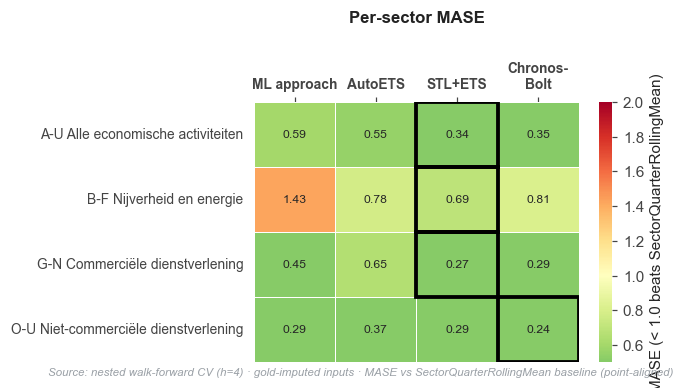

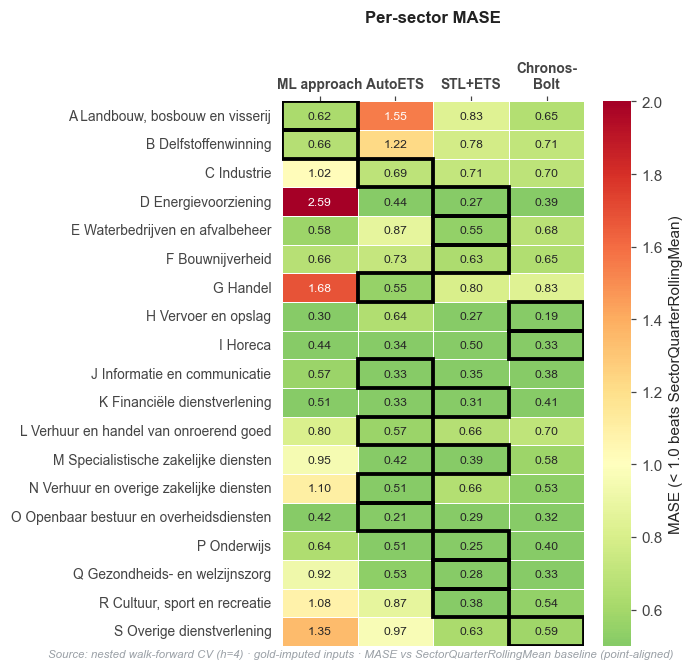

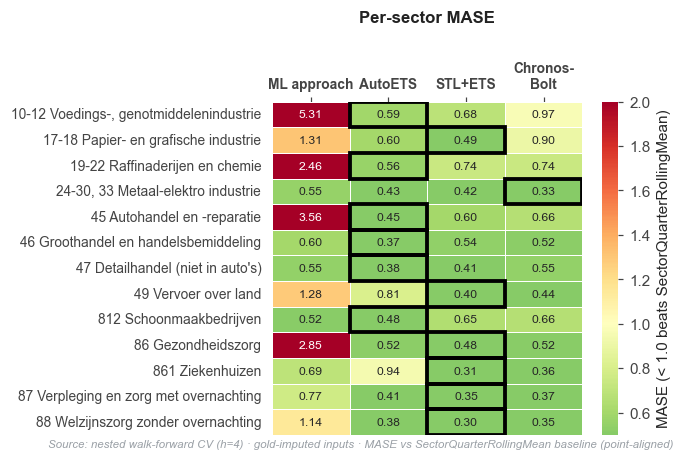

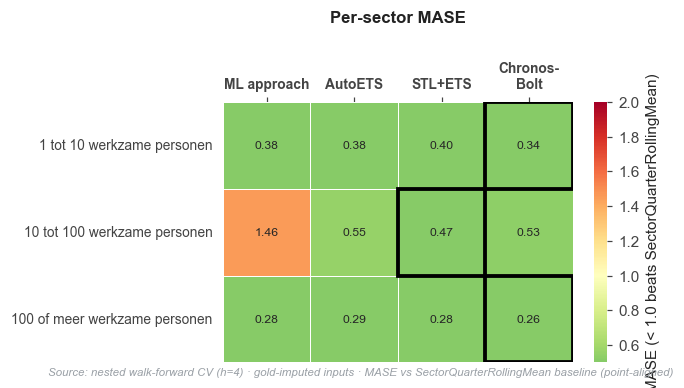

✓ All 39 sectors with prediction data were plotted across 4 category-group table(s).


In [11]:
import re
import textwrap
from collections import defaultdict
from src.utils.m_query_database import f_query_database
from src.config import DIR_DB_SILVER

# ── 1. Load SBI ordering + category groups from the silver DB ───────────
query = """
    SELECT DISTINCT
        BedrijfskenmerkenSBI2008,
        BedrijfskenmerkenSBI2008_Title,
        case when BedrijfskenmerkenSBI2008 = '301000' then 3 else BedrijfskenmerkenSBI2008_CategoryGroupID end as BedrijfskenmerkenSBI2008_CategoryGroupID
    FROM "80072ned_silver"
    ORDER BY BedrijfskenmerkenSBI2008_CategoryGroupID ASC,
             BedrijfskenmerkenSBI2008_Title ASC
"""
sbi_meta = f_query_database(DIR_DB_SILVER, query, "pandas")
sbi_meta["BedrijfskenmerkenSBI2008"] = sbi_meta["BedrijfskenmerkenSBI2008"].astype(str)

# Strip leading letter + whitespace (covers regular space, non-breaking space, tab)
def _strip_letter_prefix(code):
    code = str(code).strip()
    m = re.match(r"^[A-Za-z][\s\u00a0]+(.+)$", code)
    return m.group(1) if m else code

sbi_meta["_match_code"] = sbi_meta["BedrijfskenmerkenSBI2008"].apply(_strip_letter_prefix)

# Title lookup keyed by BOTH the original and the stripped code form.
code_to_title = {}
for _, row in sbi_meta.iterrows():
    title = row["BedrijfskenmerkenSBI2008_Title"]
    code_to_title[str(row["BedrijfskenmerkenSBI2008"])] = title
    code_to_title[row["_match_code"]] = title

def _format_label(code, max_len=55):
    title = code_to_title.get(str(code), str(code))
    return title if len(title) <= max_len else title[:max_len - 1] + "…"

# Column-header display: rename "Pipeline" → "ML approach", and wrap long
# method names onto multiple lines so headers don't overlap while the column
# WIDTH stays fixed (the heatmap cell width is set by figsize, not the label).
HEADER_RENAME = {"Pipeline": "ML approach"}
def _wrap_header(name, width=11):
    return textwrap.fill(HEADER_RENAME.get(name, name), width=width)

# Normalised category-group lookup.  The raw column can arrive as a string
# ("1"), float (1.0), int (1), or NULL; `.isin([1,2,...])` with Python ints
# silently matches NONE of those string/float forms — which is the bug that
# emptied every group.  Coerce to int where possible; NULL/blank → None.
def _norm_group(v):
    if pd.isna(v):
        return None
    try:
        return int(float(v))
    except (ValueError, TypeError):
        s = str(v).strip()
        return s if s else None

code_to_group = {}
for _, row in sbi_meta.iterrows():
    g = _norm_group(row["BedrijfskenmerkenSBI2008_CategoryGroupID"])
    code_to_group[str(row["BedrijfskenmerkenSBI2008"])] = g
    code_to_group[row["_match_code"]] = g

# ── 2. Build sector × method MASE matrix (once) ─────────────────────────
mase_matrix = per_sector.pivot(index="sector_code", columns="method", values="MASE")
present_methods = [m for m in METHOD_ORDER if m in mase_matrix.columns]
mase_matrix = mase_matrix[present_methods]
mase_matrix.columns = [METHOD_LABELS[c] for c in mase_matrix.columns]

# Collapse the two Chronos-Bolt variants (zero-shot + corrected) into ONE
# column holding the better (lower) MASE per sector.
_chronos_cols = [c for c in ("Chronos-Bolt", "Chronos-Bolt (corr.)")
                 if c in mase_matrix.columns]
if len(_chronos_cols) > 1:
    _best_chronos = mase_matrix[_chronos_cols].min(axis=1)
    mase_matrix = mase_matrix.drop(columns=_chronos_cols)
    mase_matrix["Chronos-Bolt"] = _best_chronos
elif len(_chronos_cols) == 1:                       # only one variant present
    mase_matrix = mase_matrix.rename(columns={_chronos_cols[0]: "Chronos-Bolt (best)"})

winner_by_sector = mase_matrix.idxmin(axis=1)

# ── Diagnostic: code + group alignment between sources ──────────────────
direct_overlap     = set(mase_matrix.index) & set(sbi_meta["BedrijfskenmerkenSBI2008"])
normalized_overlap = set(mase_matrix.index) & set(sbi_meta["_match_code"])
_raw_groups = sbi_meta["BedrijfskenmerkenSBI2008_CategoryGroupID"]
print("Code matching summary:")
print(f"  per_sector sectors:       {len(mase_matrix.index):>3d}")
print(f"  silver DB rows:           {len(sbi_meta):>3d}")
print(f"  direct match:             {len(direct_overlap):>3d}")
print(f"  match after prefix strip: {len(normalized_overlap):>3d}")
print(f"  CategoryGroupID dtype:    {_raw_groups.dtype} | "
      f"raw sample: {_raw_groups.dropna().unique()[:8].tolist()}")
print(f"  normalised groups present: "
      f"{sorted({g for g in code_to_group.values() if g is not None}, key=str)}")
print()

# ── 3. Plotter — column headers on TOP (wrapped, fixed width) ───────────
def _plot_mase_heatmap(codes, title):
    if not codes:
        print(f"({title}: no sectors to show)")
        return
    sub         = mase_matrix.loc[codes]
    sub_display = sub.copy()
    sub_display.index   = [_format_label(s) for s in codes]
    sub_display.columns = [_wrap_header(c) for c in sub.columns]   # rename + wrap

    fig, ax = plt.subplots(figsize=(1.6 + 1.15 * len(sub.columns),
                                    max(3.5, len(codes) * 0.32)))
    sns.heatmap(
        sub_display, annot=True, fmt=".2f",
        cmap="RdYlGn_r", center=1.0, vmin=0.5, vmax=2.0,
        linewidths=0.5, ax=ax,
        cbar_kws={"label": "MASE (< 1.0 beats SectorQuarterRollingMean)"},
        annot_kws={"size": 8},
    )
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center", va="bottom",
             fontweight="bold", fontsize=9)

    for i, sec in enumerate(codes):
        win = winner_by_sector[sec]
        j   = list(sub.columns).index(win)
        winner_value = sub.loc[sec, win]
        if winner_value < 1.0:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                        edgecolor="black", lw=2.5))
        else:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                        edgecolor="#444", lw=1.5, linestyle="--"))

    # Extra top padding so the multi-line headers clear the title.
    ax.set_title(title, fontsize=11, fontweight="bold", pad=52)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=9)
    plt.tight_layout()
    add_source_note(fig)
    plt.show()

# ── 4. Group the AVAILABLE sectors by their actual category group ───────
# Every sector that has prediction data is assigned to exactly one group, so
# nothing is silently dropped.  Sectors with no usable group id (NULL — e.g.
# aggregates / UWV groupings) land in a dedicated "Ungrouped" table.
available_codes = list(mase_matrix.index)
group_to_codes = defaultdict(list)
truly_missing  = []
for code in available_codes:
    key = str(code)
    if key in code_to_group:
        group_to_codes[code_to_group[key]].append(code)
    elif _strip_letter_prefix(key) in code_to_group:
        group_to_codes[code_to_group[_strip_letter_prefix(key)]].append(code)
    else:
        truly_missing.append(code)   # in predictions but not in the silver DB at all

# Emit order: 1 & 2 combined (if present), then remaining ints ascending, then
# any string-labelled groups, then the ungrouped/aggregate bucket last.
def _ordered_groupings():
    present = set(group_to_codes)
    out = []
    combo = [g for g in (1, 2) if g in present]
    if combo:
        out.append(("1 + 2", [c for g in combo for c in group_to_codes[g]]))
        present -= set(combo)
    for g in sorted(x for x in present if isinstance(x, int)):
        out.append((str(g), group_to_codes[g])); present.discard(g)
    for g in sorted((x for x in present if isinstance(x, str)), key=str):
        out.append((g, group_to_codes[g])); present.discard(g)
    if None in present:
        out.append(("Ungrouped (aggregates / UWV groupings)", group_to_codes[None]))
    return out

for label, codes_in_group in _ordered_groupings():
    if not codes_in_group:
        continue
    _plot_mase_heatmap(
        codes_in_group,
        f"Per-sector MASE"
    )

# ── 5. Diagnostic: sectors in predictions but genuinely absent from silver ──
if truly_missing:
    print(f"\n⚠  {len(truly_missing)} sectors with predictions are NOT in the silver DB "
          f"and were not plotted:")
    for code in sorted(truly_missing):
        print(f"    {code}")
else:
    n_plotted = sum(len(c) for _, c in _ordered_groupings())
    print(f"✓ All {n_plotted} sectors with prediction data were plotted across "
          f"{len(_ordered_groupings())} category-group table(s).")

In [33]:
# [Consolidated]  Baseline, SBI titles and per-method best-configs are now all
# loaded once, robustly, in the loader cell at the top of section 1.  This cell
# is intentionally a no-op so the variables defined there are not overwritten by
# a second, divergent loader (the previous notebook had two slightly different
# baseline loaders here, and whichever ran last silently won).
assert "baseline_mae" in dir(),  "run the section-1 loader cell first"
assert "sbi_titles"   in dir(),  "run the section-1 loader cell first"
print("Baseline / titles / settings already loaded above — "
      f"baseline sectors: {len(baseline_mae)}, titles: {len(sbi_titles)}.")

Baseline / titles / settings already loaded above — baseline sectors: 39, titles: 39.


,method,mean_mase,median_mase,n_beat_naive,n_sectors,pct_beat_naive
0,STL+ETS,0.478,0.420,39,39,100.0%
1,Chronos-Bolt,0.520,0.528,39,39,100.0%
2,Chronos-Bolt (corr.),0.523,0.518,39,39,100.0%
3,AutoETS,0.584,0.527,37,39,94.9%
4,Pipeline,1.112,0.688,24,39,61.5%



STL+ETS                mean MASE = 0.478  (beats SectorQuarterRollingMean on average, 39/39 sectors)
Chronos-Bolt           mean MASE = 0.520  (beats SectorQuarterRollingMean on average, 39/39 sectors)
Chronos-Bolt (corr.)   mean MASE = 0.523  (beats SectorQuarterRollingMean on average, 39/39 sectors)
AutoETS                mean MASE = 0.584  (beats SectorQuarterRollingMean on average, 37/39 sectors)
Pipeline               mean MASE = 1.112  (loses to SectorQuarterRollingMean on average, 24/39 sectors)


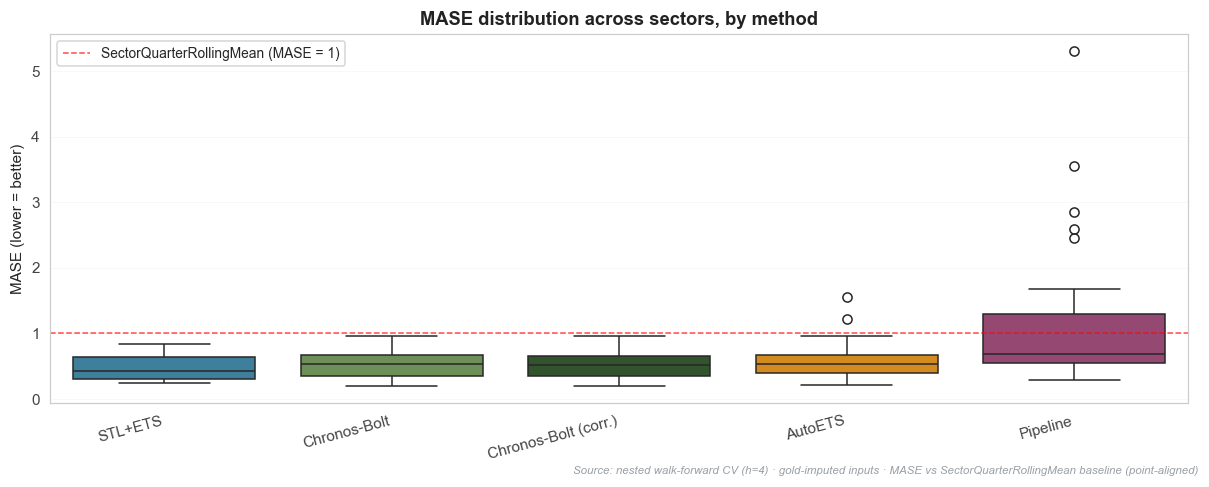

In [34]:
# Mean MASE per method, plus how many sectors beat the SectorQuarterRollingMean baseline.
# MASE < 1.0 means the method beats the SectorQuarterRollingMean baseline.
# This is the headline number for the thesis — more interpretable than raw MAE.

mase_summary = (
    per_sector.groupby("method")
              .agg(mean_mase   =("MASE", "mean"),
                   median_mase =("MASE", "median"),
                   n_beat_naive=("MASE", lambda x: int((x < 1.0).sum())),
                   n_sectors   =("MASE", "size"))
              .reset_index()
)
mase_summary["pct_beat_naive"] = (
    mase_summary["n_beat_naive"] / mase_summary["n_sectors"] * 100
).round(1).astype(str) + "%"
mase_summary = mase_summary.sort_values("mean_mase").reset_index(drop=True)
# Friendly method labels for display
mase_summary["method"] = mase_summary["method"].map(
    lambda m: METHOD_LABELS.get(m, m))

_n_sectors = int(per_sector["sector_code"].nunique())
display(
    mase_summary.style
                .format({"mean_mase": "{:.3f}", "median_mase": "{:.3f}"})
                .set_caption(f"Mean MASE across {_n_sectors} sectors — lower is "
                             "better; below 1.0 means the method beats "
                             "the SectorQuarterRollingMean baseline")
                .background_gradient(subset=["mean_mase"], cmap="RdYlGn_r")
)

# Thesis-ready sentences
print()
for _, row in mase_summary.iterrows():
    verdict = "beats" if row["mean_mase"] < 1.0 else "loses to"
    print(f"{row['method']:<22s} mean MASE = {row['mean_mase']:.3f}  "
          f"({verdict} SectorQuarterRollingMean on average, "
          f"{row['n_beat_naive']:>2d}/{row['n_sectors']} sectors)")

# Distribution view to spot bimodality / outliers.  Bars coloured per method
# using the shared palette (label -> internal key -> colour).
fig, ax = plt.subplots(figsize=(1.8 * len(mase_summary) + 2, 4.4))
order_labels = mase_summary["method"].tolist()
palette = [METHOD_COLORS.get(METHOD_LABELS_INVERSE.get(lbl, lbl), "#999999")
           for lbl in order_labels]
_per_sector_disp = per_sector.assign(
    method_label=per_sector["method"].map(lambda m: METHOD_LABELS.get(m, m)))
sns.boxplot(data=_per_sector_disp, x="method_label", y="MASE",
            order=order_labels, hue="method_label", legend=False,
            palette=palette, ax=ax)
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7,
           label="SectorQuarterRollingMean (MASE = 1)")
ax.set_title("MASE distribution across sectors, by method", fontweight="bold")
ax.set_ylabel("MASE (lower = better)")
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
add_source_note(fig)
plt.show()

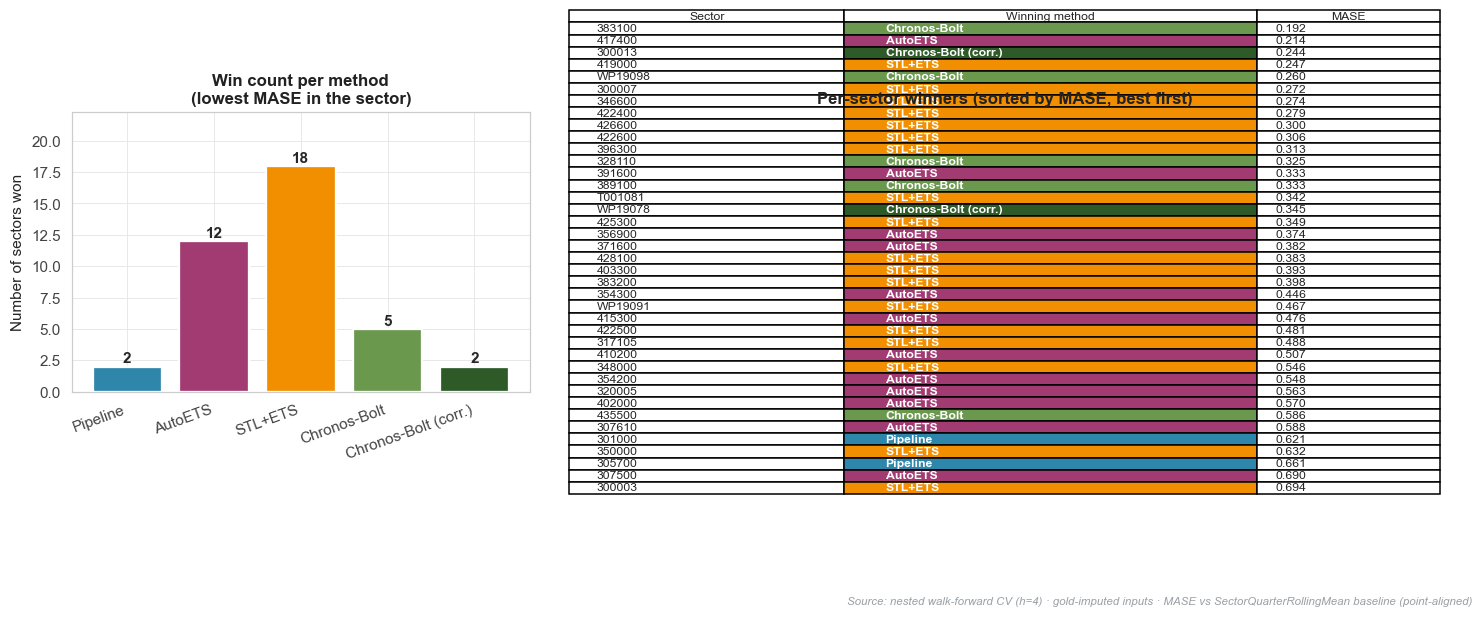

In [15]:
# Win-count bars + winner table.  "Winner" = lowest per-sector MASE.
_present_labels = [METHOD_LABELS[m] for m in PRESENT_METHODS]
win_counts = winner_by_sector.value_counts().reindex(_present_labels, fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 6.5),
                               gridspec_kw={"width_ratios": [1, 2]})

colors_for_bars = [METHOD_COLORS[m] for m in PRESENT_METHODS]
bars = ax1.bar(range(len(win_counts)), win_counts.values, color=colors_for_bars,
               edgecolor="white", linewidth=1.5)
ax1.set_xticks(range(len(win_counts)))
ax1.set_xticklabels(win_counts.index, rotation=20, ha="right")
ax1.set_ylabel("Number of sectors won")
ax1.set_title("Win count per method\n(lowest MASE in the sector)",
              fontsize=11, fontweight='bold')
for bar, v in zip(bars, win_counts.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.3, str(int(v)),
             ha="center", fontsize=10, fontweight='bold')
ax1.set_ylim(0, max(win_counts.values) * 1.18 + 1)

# Winner table — value shown is the winning (best) MASE, sorted best-first.
winners_table = pd.DataFrame({
    "sector": winner_by_sector.index,
    "winner": winner_by_sector.values,
    "MASE":   winning_mase.values,
}).sort_values("MASE").reset_index(drop=True)

ax2.axis("off")
ax2.set_title("Per-sector winners (sorted by MASE, best first)",
              fontsize=11, fontweight='bold')

table_data = [["Sector", "Winning method", "MASE"]]
for _, row in winners_table.iterrows():
    table_data.append([str(row["sector"]), str(row["winner"]),
                       f"{row['MASE']:.3f}"])

tbl = ax2.table(cellText=table_data[1:], colLabels=table_data[0],
                cellLoc='left', loc='center',
                colWidths=[0.3, 0.45, 0.2])
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.0, 1.3)

# Color the winner column by method
label_to_color = {METHOD_LABELS[m]: METHOD_COLORS[m] for m in PRESENT_METHODS}
for i, row in winners_table.iterrows():
    cell = tbl[(i + 1, 1)]
    cell.set_facecolor(label_to_color.get(row["winner"], "white"))
    cell.set_text_props(color="white", weight="bold")

plt.tight_layout()
add_source_note(fig)
plt.show()

### Reading the cross-method view

- **A dominant method (>50% of wins)** means the comparison has a clear best approach - use that as the default in the report.
- **Roughly even split** means no single method dominates and per-sector selection IS the value-add.
- **A method that never wins** is a deployment-time drop candidate, though it may still be useful as a sanity-check baseline.

The heatmap colours range from green (low MAE) to red (high MAE). A mostly-green row is an easy sector for everyone; a mostly-red row is a hard sector even for the winner. Look for narrow gaps between winning and runner-up - if the difference is tiny (e.g. 0.005 pp), interpretability/maintenance cost might justify deploying the simpler runner-up instead.


## 7. The Quadrant: Univariate × Multivariate, Explainable × Black-Box

For each sector, place a point in the quadrant of its **winning method's paradigm**:

- **X-axis**: univariate (uses only target series) vs multivariate (uses features)
- **Y-axis**: explainable (interpretable model) vs black-box (opaque)

| Method | Univariate? | Explainable? | Quadrant |
|---|---|---|---|
| AutoETS | yes | yes | bottom-left |
| STL+ETS | yes | yes | bottom-left |
| Chronos-Bolt (zero-shot) | yes | no | top-left |
| Chronos-Bolt (corr.) | yes | no | top-left |
| Pipeline (Ridge / ElasticNet / PLS) | no | yes | bottom-right |
| Pipeline (HistGBR) | no | no | top-right |

Both Chronos forms are univariate foundation models, so they share the **top-left** quadrant; they are coloured distinctly (light vs dark green) so you can see which form actually won a sector.

**What this answers**: does the data demand a particular paradigm, or are the wins distributed across them?

- **Heavy bottom-left**: simple statistical methods are enough; the engineered features aren't pulling weight
- **Heavy bottom-right**: features earn their keep, but linear models capture the structure
- **Heavy top-right**: non-linear feature interactions matter
- **Heavy top-left**: foundation model priors beat your engineered features — unusual and interesting

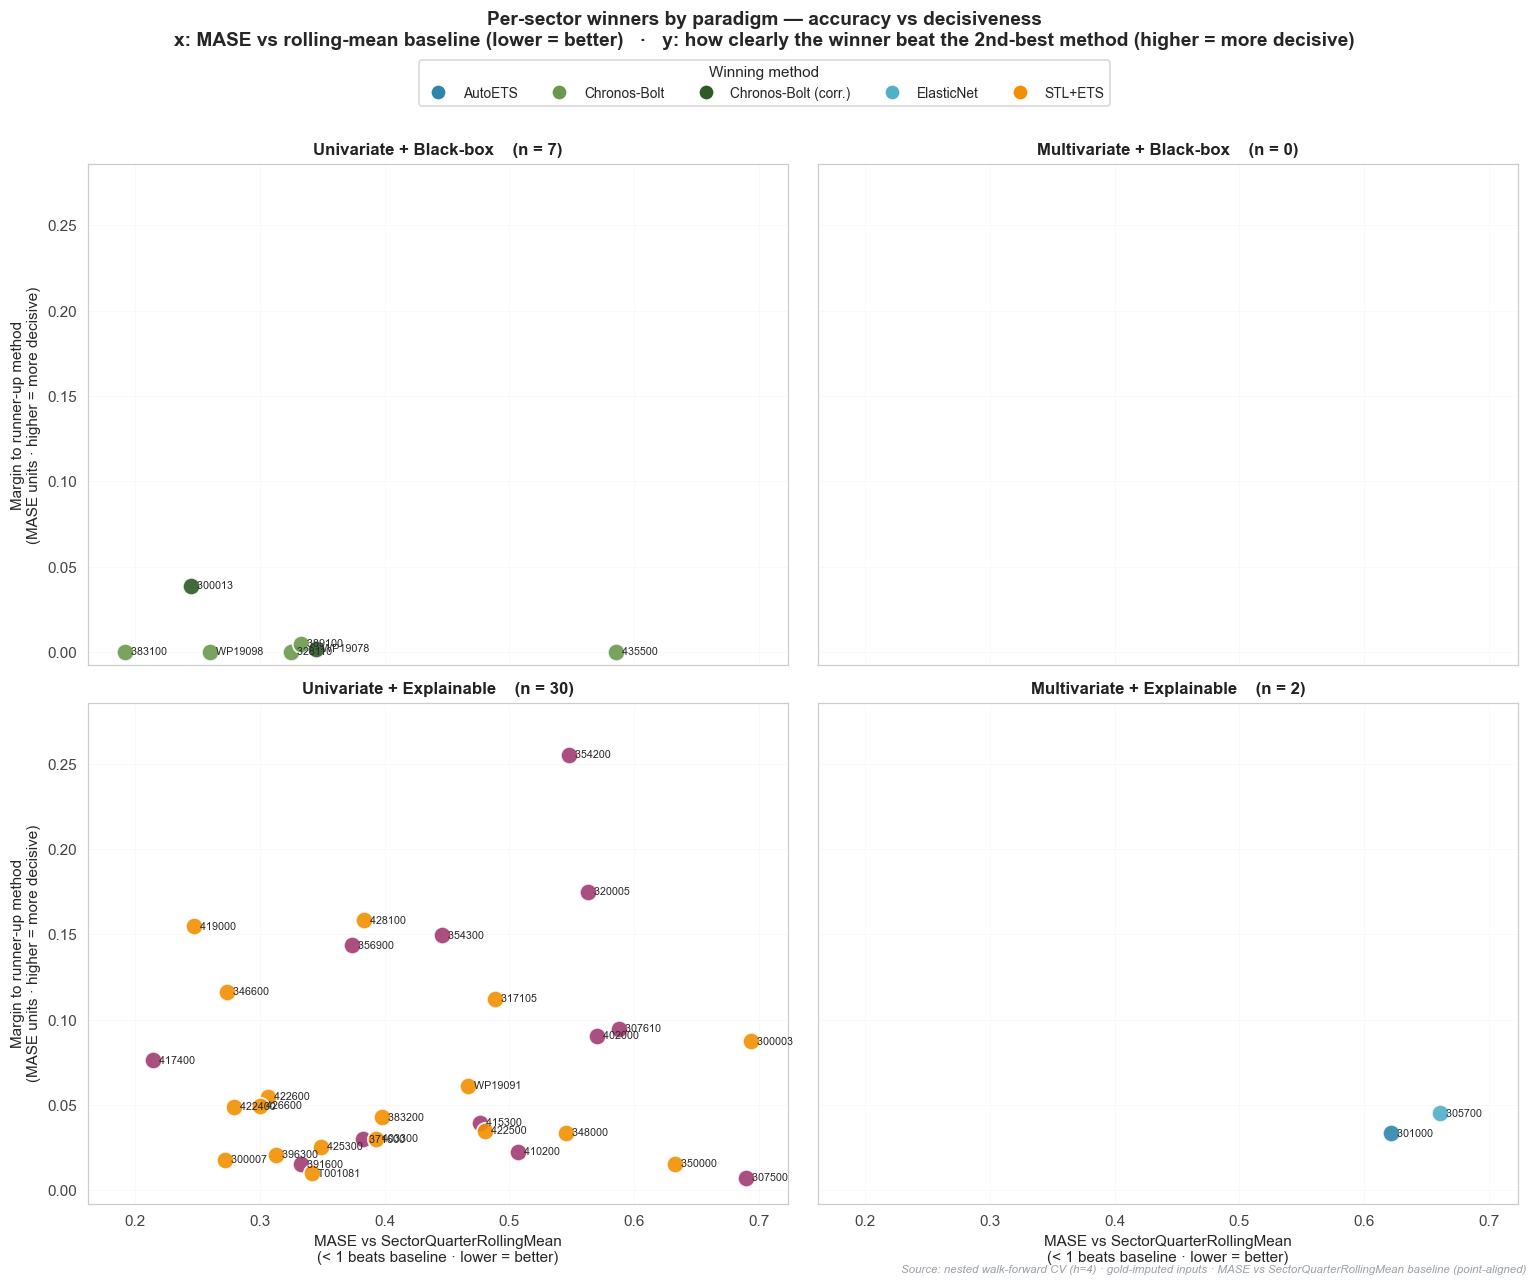

Sectors per quadrant (and median margin to runner-up):
  Uni + Explainable     : 30 sectors | median margin = 0.049 MASE
  Uni + Black-box       :  7 sectors | median margin = 0.000 MASE
  Multi + Explainable   :  2 sectors | median margin = 0.039 MASE
  Multi + Black-box     :  0 sectors | median margin = nan MASE


In [16]:
def classify_quadrant(method_label, variant=None):
    """Returns (x, y) quadrant centres: x<0 univariate / x>0 multivariate;
    y<0 explainable / y>0 black-box.  For Pipeline the winning variant decides
    explainable (linear) vs black-box (tree/boosting)."""
    UNI_X, MULTI_X  = -0.5, 0.5
    EXPL_Y, BLACK_Y = -0.5, 0.5
    if method_label == "Pipeline":
        if variant is None:
            return MULTI_X, EXPL_Y
        v = variant.lower()
        if any(tok in v for tok in ("hist", "boost", "forest", "rf", "xgb")):
            return MULTI_X, BLACK_Y
        return MULTI_X, EXPL_Y
    if method_label == "AutoETS":              return UNI_X, EXPL_Y
    if method_label == "STL+ETS":              return UNI_X, EXPL_Y
    if method_label == "Chronos-Bolt":         return UNI_X, BLACK_Y
    if method_label == "Chronos-Bolt (corr.)": return UNI_X, BLACK_Y
    return 0.0, 0.0

# ── Pipeline winners are renamed to their actual model family ────────────────
# winning_variant looks like "PLS_Reduced_300003" / "HistGBR_Reduced_389100".
def _pipeline_family(variant, sector_code):
    if not variant:
        return "Pipeline"
    v = str(variant)
    suf = f"_{sector_code}"
    v = v[:-len(suf)] if v.endswith(suf) else v.rsplit("_", 1)[0]
    return v.replace("_Reduced", "").replace("_Stat", "")

# Distinct colours: linear Pipeline families in the blue/teal family,
# tree/boosting families in the purple family; univariate methods keep theirs.
PIPELINE_FAMILY_COLORS = {
    "Ridge": "#2E86AB", "ElasticNet": "#4FB0C6", "PLS": "#1B6B8C", "Lasso": "#7FB7D6",
    "HistGBR": "#6A4C93", "RandomForest": "#A06CD5", "GradientBoosting": "#5E3C99",
    "XGBoost": "#7B52AB",
}

def _display_and_color(winner_label, variant, sector_code):
    if winner_label == "Pipeline":
        fam = _pipeline_family(variant, sector_code)
        return fam, PIPELINE_FAMILY_COLORS.get(fam, METHOD_COLORS["Pipeline"])
    key = METHOD_LABELS_INVERSE.get(winner_label, winner_label)
    return winner_label, METHOD_COLORS.get(key, "gray")

# ── Margin to the runner-up method (decisiveness of the per-sector winner) ──
def _runner_up_margin(row):
    vals = np.sort(row.dropna().values)
    return float(vals[1] - vals[0]) if len(vals) >= 2 else np.nan

margin_by_sector = mase_matrix.apply(_runner_up_margin, axis=1)

pipeline_variant_lookup = dict(zip(
    pipeline_winners["sector_code"].astype(str),
    pipeline_winners["winning_variant"],
))

recs = []
for sec in winner_by_sector.index:
    wlabel  = winner_by_sector[sec]
    variant = pipeline_variant_lookup.get(str(sec)) if wlabel == "Pipeline" else None
    qx, qy  = classify_quadrant(wlabel, variant)
    disp, color = _display_and_color(wlabel, variant, str(sec))
    recs.append({
        "sector":   sec,
        "uni":      qx < 0,        # True = univariate (left column)
        "blackbox": qy > 0,        # True = black-box (top row)
        "mase":     float(winning_mase[sec]),
        "margin":   margin_by_sector.get(sec, np.nan),
        "disp":     disp, "color": color,
    })
qdf = pd.DataFrame(recs)
qdf["margin"] = qdf["margin"].fillna(0.0)

# ── Shared axis limits across all four panels ───────────────────────────────
_xpad = max(0.03, 0.05 * (qdf["mase"].max() - qdf["mase"].min()))
xlim = (min(qdf["mase"].min() - _xpad, 0.97), qdf["mase"].max() + _xpad)
ylim = (-0.03 * max(qdf["margin"].max(), 0.05),
        max(qdf["margin"].max() * 1.12, 0.05))

# ── 2×2 facet: panel = paradigm; within-panel = real metric axes ────────────
panels = {
    (0, 0): ("Univariate + Black-box",     True,  True),
    (0, 1): ("Multivariate + Black-box",   False, True),
    (1, 0): ("Univariate + Explainable",   True,  False),
    (1, 1): ("Multivariate + Explainable", False, False),
}
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True)
for (r, c), (title, want_uni, want_bb) in panels.items():
    ax  = axes[r, c]
    sub = qdf[(qdf["uni"] == want_uni) & (qdf["blackbox"] == want_bb)]
    ax.axvline(1.0, color="#999999", ls="--", lw=1, alpha=0.7, zorder=1)  # beats-baseline
    for _, row in sub.iterrows():
        ax.scatter(row["mase"], row["margin"], s=130, color=row["color"],
                   edgecolor="white", linewidth=1.2, alpha=0.9, zorder=3)
        ax.text(row["mase"], row["margin"], f"  {row['sector']}", fontsize=7,
                va="center", ha="left", zorder=4)
    ax.set_title(f"{title}    (n = {len(sub)})", fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.25)
    if r == 1:
        ax.set_xlabel("MASE vs SectorQuarterRollingMean\n(< 1 beats baseline · lower = better)")
    if c == 0:
        ax.set_ylabel("Margin to runner-up method\n(MASE units · higher = more decisive)")
axes[0, 0].set_xlim(*xlim)
axes[0, 0].set_ylim(*ylim)

# Legend: actual winning methods present (Pipeline expanded to families)
present = (qdf.drop_duplicates("disp").sort_values("disp")[["disp", "color"]])
legend_elements = [Line2D([0], [0], marker="o", color="w", markerfacecolor=cc,
                          markersize=10, label=dd)
                   for dd, cc in zip(present["disp"], present["color"])]
fig.legend(handles=legend_elements, loc="upper center",
           ncol=min(len(legend_elements), 6), bbox_to_anchor=(0.5, 1.015),
           frameon=True, title="Winning method")

plt.suptitle("Per-sector winners by paradigm — accuracy vs decisiveness\n"
             "x: MASE vs rolling-mean baseline (lower = better)   ·   "
             "y: how clearly the winner beat the 2nd-best method (higher = more decisive)",
             fontsize=12.5, fontweight="bold", y=1.05)
plt.tight_layout()
add_source_note(fig)
plt.show()

# Console summary: per quadrant + decisiveness
print("Sectors per quadrant (and median margin to runner-up):")
for (title, wu, wb) in [("Uni + Explainable", True, False), ("Uni + Black-box", True, True),
                        ("Multi + Explainable", False, False), ("Multi + Black-box", False, True)]:
    s = qdf[(qdf["uni"] == wu) & (qdf["blackbox"] == wb)]
    med = s["margin"].median() if len(s) else float("nan")
    print(f"  {title:22s}: {len(s):2d} sectors | median margin = {med:.3f} MASE")

### Interpreting the quadrant

- A **heavily clustered quadrant** is a clear modelling preference for this data - put it in the report.
- Sectors near a quadrant **border** (where MAE differences are small) are good simpler-model candidates even if a fancier one technically won; deployment cost and interpretability matter.
- **Outliers in unexpected quadrants** deserve manual investigation: why does *this* sector get won by *that* paradigm?


## 8. Per-Horizon Decay

How much does error compound as we forecast further ahead? All models degrade, but at different rates. The right panel normalizes by each method's h=1 error so the *shape* of the decay is comparable across methods at different scales.


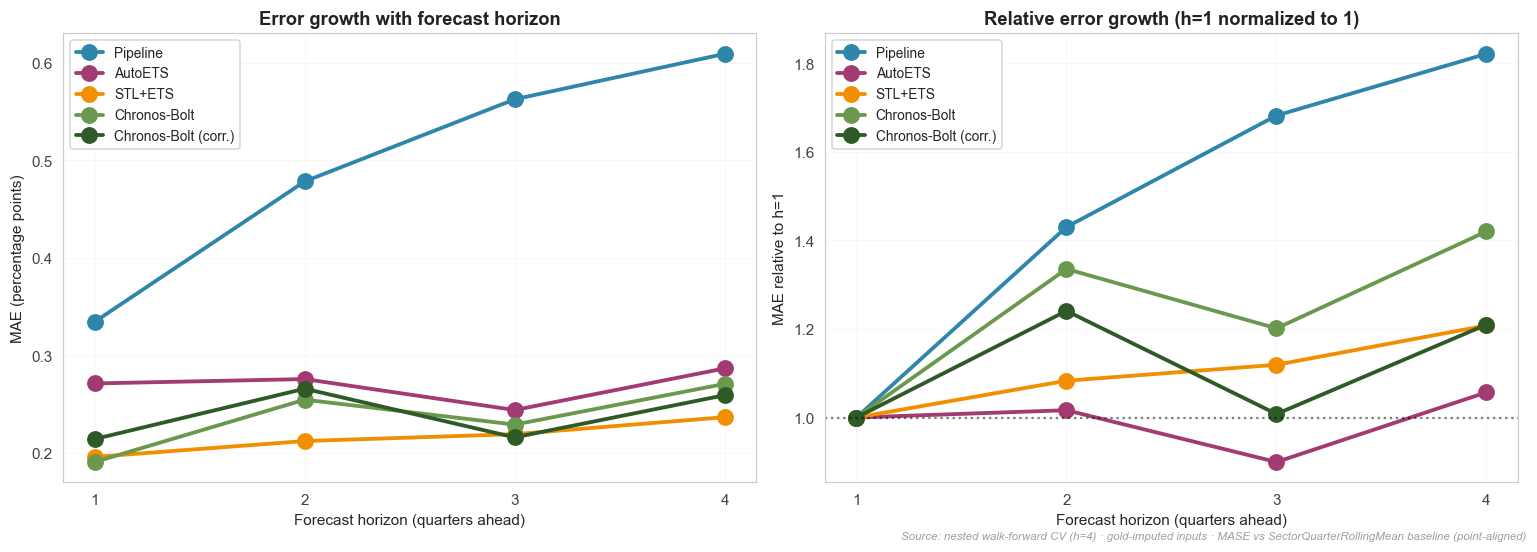


MAE by horizon:
horizon                    1       2       3       4
method                                              
Pipeline              0.3345  0.4785  0.5627  0.6094
AutoETS               0.2713  0.2757  0.2440  0.2867
STL+ETS               0.1959  0.2122  0.2192  0.2366
Chronos-Bolt          0.1906  0.2546  0.2290  0.2708
Chronos-Bolt (corr.)  0.2142  0.2658  0.2159  0.2592


In [17]:
horizon_rows = []
for (method, h), g in aligned.groupby(["model_name", "horizon"]):
    m = compute_metrics(g, NAIVE_BASELINES)
    m.update({"method": METHOD_LABELS[method], "horizon": h})
    horizon_rows.append(m)
horizon_df = pd.DataFrame(horizon_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Absolute MAE by horizon
for method in PRESENT_METHODS:
    sub = horizon_df[horizon_df["method"] == METHOD_LABELS[method]].sort_values("horizon")
    if sub.empty: continue
    axes[0].plot(sub["horizon"], sub["MAE"], marker="o", linewidth=2.5,
                 markersize=10, color=METHOD_COLORS[method],
                 label=METHOD_LABELS[method])
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xlabel("Forecast horizon (quarters ahead)")
axes[0].set_ylabel("MAE (percentage points)")
axes[0].set_title("Error growth with forecast horizon", fontsize=12, fontweight='bold')
axes[0].legend(loc="upper left")
axes[0].grid(True, alpha=0.3)

# Relative degradation
for method in PRESENT_METHODS:
    sub = horizon_df[horizon_df["method"] == METHOD_LABELS[method]].sort_values("horizon")
    if sub.empty or not (sub["horizon"] == 1).any():
        continue
    h1 = sub[sub["horizon"] == 1]["MAE"].iloc[0]
    rel = sub["MAE"] / h1
    axes[1].plot(sub["horizon"], rel, marker="o", linewidth=2.5,
                 markersize=10, color=METHOD_COLORS[method],
                 label=METHOD_LABELS[method])
axes[1].set_xticks([1, 2, 3, 4])
axes[1].set_xlabel("Forecast horizon (quarters ahead)")
axes[1].set_ylabel("MAE relative to h=1")
axes[1].set_title("Relative error growth (h=1 normalized to 1)",
                  fontsize=12, fontweight='bold')
axes[1].axhline(1.0, color="black", linestyle=":", alpha=0.5)
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
add_source_note(fig)
plt.show()

# Numerical table
horizon_table = horizon_df.pivot(index="method", columns="horizon", values="MAE")
horizon_table = horizon_table.reindex([METHOD_LABELS[m] for m in PRESENT_METHODS])
print("\nMAE by horizon:")
print(horizon_table.round(4).to_string())

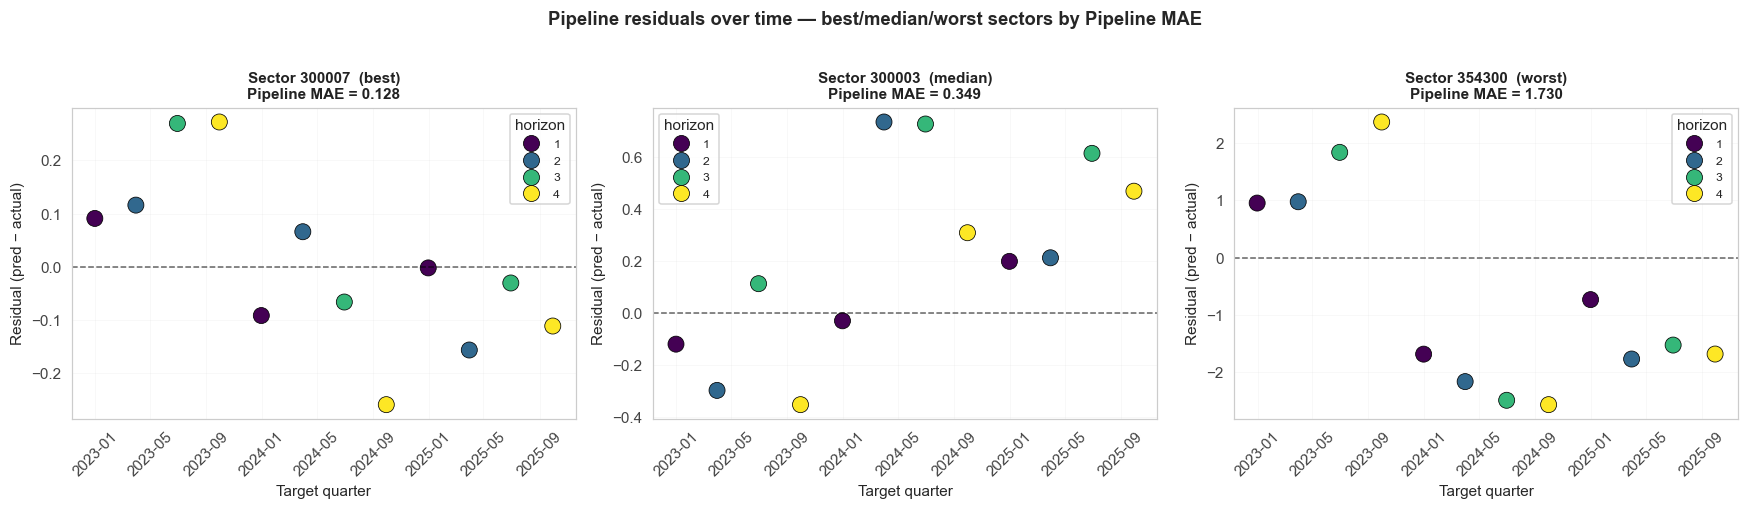

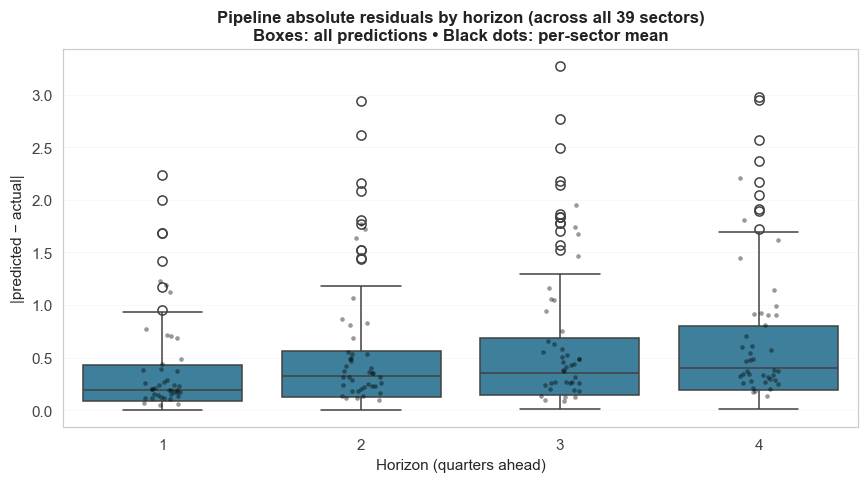

Pipeline absolute residuals by horizon (median ± IQR across all predictions):
  h=1: median=0.195  IQR=[0.084, 0.431]  max=2.237
  h=2: median=0.323  IQR=[0.126, 0.563]  max=2.945
  h=3: median=0.354  IQR=[0.140, 0.685]  max=3.274
  h=4: median=0.399  IQR=[0.188, 0.802]  max=2.976


In [18]:
# Pipeline residuals — investigate whether the error is regime-specific
# (concentrated in particular quarters) or structural (uniformly bad at long horizons).

# Pick representative sectors: best / median / worst Pipeline MAE.
pipeline_mae_by_sector = (
    pipeline.assign(_ae=lambda d: (d["y_pred"] - d["y_true"]).abs())
            .groupby("sector_code")["_ae"]
            .mean()
            .sort_values()
)
example_sectors = [
    pipeline_mae_by_sector.index[0],                                    # best
    pipeline_mae_by_sector.index[len(pipeline_mae_by_sector) // 2],     # median
    pipeline_mae_by_sector.index[-1],                                   # worst
]
example_labels = ["best", "median", "worst"]

# --- Subplots: one per chosen sector, residuals over time, colored by horizon ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=False)
for ax, sector, label in zip(axes, example_sectors, example_labels):
    sub = (pipeline[pipeline["sector_code"] == sector]
                 .assign(residual=lambda d: d["y_pred"] - d["y_true"])
                 .sort_values("target_date")
                 .copy())
    sns.scatterplot(
        data=sub, x="target_date", y="residual",
        hue="horizon", palette="viridis",
        s=110, edgecolor="black", linewidth=0.5, ax=ax,
    )
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
    mae = sub["residual"].abs().mean()
    ax.set_title(f"Sector {sector}  ({label})\nPipeline MAE = {mae:.3f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Target quarter")
    ax.set_ylabel("Residual (pred − actual)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)
    ax.legend(title="horizon", loc="best", fontsize=8)

plt.suptitle("Pipeline residuals over time — best/median/worst sectors by Pipeline MAE",
             y=1.02, fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

# --- Direct answer to "does h=4 explode?": absolute residuals by horizon ---
pipeline_all = pipeline.assign(abs_residual=lambda d: (d["y_pred"] - d["y_true"]).abs())

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(
    data=pipeline_all, x="horizon", y="abs_residual",
    color=METHOD_COLORS.get("Pipeline", "#2E86AB"),
    showfliers=True, ax=ax,
)
sns.stripplot(
    data=pipeline_all.groupby(["sector_code", "horizon"])["abs_residual"].mean().reset_index(),
    x="horizon", y="abs_residual",
    color="black", alpha=0.4, size=3, ax=ax,
)
ax.set_title("Pipeline absolute residuals by horizon (across all 39 sectors)\n"
             "Boxes: all predictions • Black dots: per-sector mean",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Horizon (quarters ahead)")
ax.set_ylabel("|predicted − actual|")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# Numeric summary
print("Pipeline absolute residuals by horizon (median ± IQR across all predictions):")
for h in sorted(pipeline_all["horizon"].unique()):
    s = pipeline_all[pipeline_all["horizon"] == h]["abs_residual"]
    print(f"  h={h}: median={s.median():.3f}  IQR=[{s.quantile(0.25):.3f}, {s.quantile(0.75):.3f}]  "
          f"max={s.max():.3f}")

## 9. Regime Performance: Pre-COVID / COVID / Post-Recovery

Forecasting accuracy depends heavily on the regime. Most methods do well in the stable pre-COVID period; the meaningful differences emerge in the post-2023 "new normal".

The method that holds up post-2023 is the one to deploy.


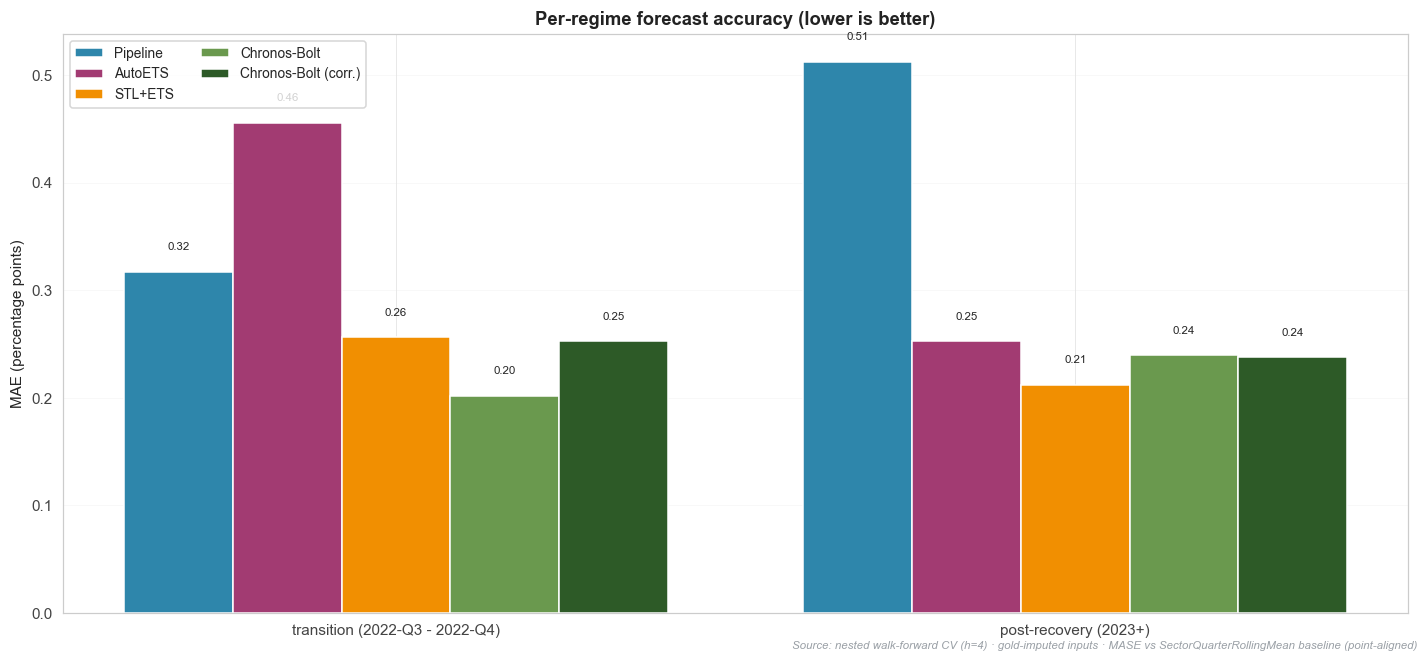

In [32]:
al = aligned.copy()
al["target_date"] = pd.to_datetime(al["target_date"])

def regime_label(d):
    if d < pd.Timestamp("2020-03-31"):
        return "pre-COVID (<=2019)"
    elif d <= pd.Timestamp("2022-06-30"):
        return "COVID (2020-Q1 - 2022-Q2)"
    elif d >= pd.Timestamp("2023-01-01"):
        return "post-recovery (2023+)"
    return "transition (2022-Q3 - 2022-Q4)"

al["regime"] = al["target_date"].map(regime_label)
regime_order = ["pre-COVID (<=2019)", "COVID (2020-Q1 - 2022-Q2)",
                "transition (2022-Q3 - 2022-Q4)", "post-recovery (2023+)"]

regime_rows = []
for (method, reg), g in al.groupby(["model_name", "regime"]):
    if len(g) < 5: continue
    m = compute_metrics(g, NAIVE_BASELINES)
    m.update({"method": METHOD_LABELS[method], "regime": reg})
    regime_rows.append(m)
regime_df = pd.DataFrame(regime_rows)

fig, ax = plt.subplots(figsize=(13, 6))
regimes_present = [r for r in regime_order if r in regime_df["regime"].unique()]
n_methods = len(PRESENT_METHODS)
n_regimes = len(regimes_present)
width = 0.8 / n_methods

for i, method in enumerate(PRESENT_METHODS):
    vals = []
    for reg in regimes_present:
        sub = regime_df[(regime_df["method"] == METHOD_LABELS[method]) &
                        (regime_df["regime"] == reg)]
        vals.append(sub["MAE"].iloc[0] if len(sub) else np.nan)
    xpos = np.arange(n_regimes) + i * width
    ax.bar(xpos, vals, width, color=METHOD_COLORS[method],
           label=METHOD_LABELS[method], edgecolor="white", linewidth=1)
    for x, v in zip(xpos, vals):
        if not np.isnan(v):
            ax.text(x, v + 0.02, f"{v:.2f}", ha="center", fontsize=7.5)

ax.set_xticks(np.arange(n_regimes) + width * (n_methods - 1) / 2)
ax.set_xticklabels(regimes_present, fontsize=10)
ax.set_ylabel("MAE (percentage points)")
ax.set_title("Per-regime forecast accuracy (lower is better)",
             fontsize=12, fontweight='bold')
ax.legend(loc="upper left", ncol=2)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
add_source_note(fig)
plt.show()

### Regime narrative for the report

If all methods get worse post-2023 by similar amounts, that's a structural data problem - the world genuinely changed - not a model problem. State it explicitly in the limitations.

If one method holds up where others collapse, that's your deployment recommendation.


## 10. Statistical Significance

Two questions:

1. **Friedman test**: are the rankings of methods across sectors significantly different from random?
2. **Diebold-Mariano (pairwise)**: which specific method-pair differences are statistically significant?

If the Friedman p-value is small (<0.05), at least one method genuinely differs from the others. The pairwise DM matrix tells you *which* differences are real.

If p > 0.05, choose your method on interpretability, runtime, and maintainability rather than raw accuracy.


Friedman omnibus p-value: 0.0000
Sectors evaluated: 39

Mean ranks (lower = better):
  STL+ETS       : 2.10
  Chronos-Bolt  : 2.74
  Chronos-Bolt (corr.): 2.74
  AutoETS       : 3.00
  Pipeline      : 4.41

Nemenyi critical difference (alpha=0.05): 0.977
  Methods whose mean ranks differ by more than 0.977 are significantly different at the family-wise alpha=0.05 level.


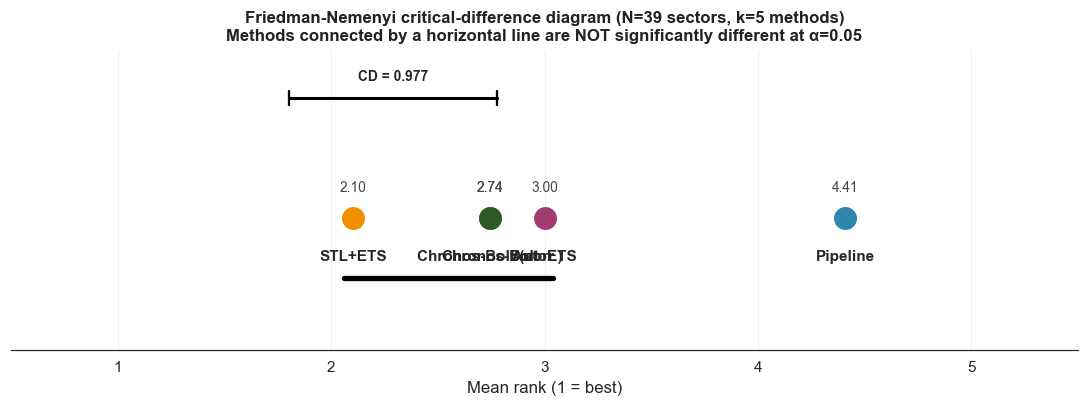


Pairwise Diebold-Mariano p-values (raw / Holm-adjusted; * = significant at alpha=0.05):
                             AutoETS    Chronos-Bolt Chronos-Bolt (corr.)        Pipeline         STL+ETS
AutoETS                  1.0000/nan   0.0074/0.0215*       0.0072/0.0215*  0.0000/0.0000*  0.0000/0.0000*
Chronos-Bolt          0.0074/0.0215*     1.0000/nan        0.6586/0.6586   0.0000/0.0000*  0.0000/0.0002*
Chronos-Bolt (corr.)  0.0072/0.0215*  0.6586/0.6586           1.0000/nan   0.0000/0.0000*  0.0000/0.0002*
Pipeline              0.0000/0.0000*  0.0000/0.0000*       0.0000/0.0000*     1.0000/nan   0.0000/0.0000*
STL+ETS               0.0000/0.0000*  0.0000/0.0002*       0.0000/0.0002*  0.0000/0.0000*     1.0000/nan 

Win-loss matrix (row beats column on N sectors at p < 0.05, raw):
                      AutoETS Chronos-Bolt Chronos-Bolt (corr.) Pipeline  STL+ETS
AutoETS                     —       1-6-32               2-8-29  12-4-23   3-9-27
Chronos-Bolt           6-1-32            —  

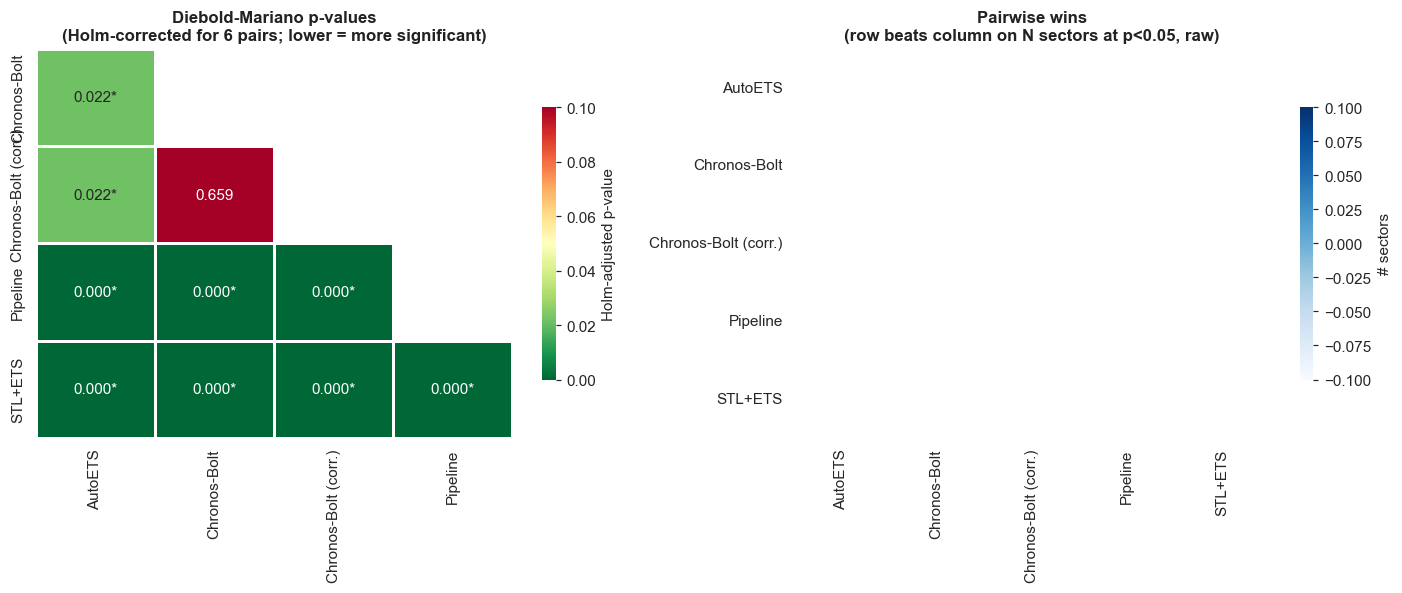

In [20]:
# Friedman-Nemenyi (rank-based, non-parametric, properly controls family-wise
# error rate via Critical Difference) and Diebold-Mariano with Holm-Bonferroni
# correction for multiple comparisons (k(k-1)/2 = 6 pair tests).

try:
    fr = friedman_nemenyi(aligned)
    print(f"Friedman omnibus p-value: {fr.get('friedman_p'):.4f}")
    print(f"Sectors evaluated: {fr.get('n_sectors')}")
    if fr.get('mean_ranks'):
        print(f"\nMean ranks (lower = better):")
        for m, r in sorted(fr['mean_ranks'].items(), key=lambda kv: kv[1]):
            print(f"  {METHOD_LABELS.get(m, m):14s}: {r:.2f}")

        # --- Critical-difference diagram (Demšar 2006 style) ---
        k = len(fr['mean_ranks'])
        N = fr['n_sectors']
        try:
            from scipy.stats import studentized_range
            q_alpha = studentized_range.ppf(0.95, k, np.inf) / np.sqrt(2)
        except (ImportError, AttributeError):
            q_alpha = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850}.get(k, 2.569)
        CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
        print(f"\nNemenyi critical difference (alpha=0.05): {CD:.3f}")
        print(f"  Methods whose mean ranks differ by more than {CD:.3f} are "
              f"significantly different at the family-wise alpha=0.05 level.")

        sorted_items   = sorted(fr['mean_ranks'].items(), key=lambda kv: kv[1])
        methods_keys   = [m for m, _ in sorted_items]
        methods_labels = [METHOD_LABELS.get(m, m) for m in methods_keys]
        ranks          = [r for _, r in sorted_items]

        with sns.axes_style("white"):
            fig, ax = plt.subplots(figsize=(10, 3.8))
            y_dot = 0.55
            for i, (label, rank, mkey) in enumerate(zip(methods_labels, ranks, methods_keys)):
                color = METHOD_COLORS.get(mkey, "gray")
                ax.plot(rank, y_dot, "o", markersize=14, color=color, zorder=3)
                ax.text(rank, y_dot - 0.18, label,           ha="center", fontsize=10, fontweight="bold")
                ax.text(rank, y_dot + 0.11, f"{rank:.2f}",   ha="center", fontsize=9,  color="#444")

            x0 = max(0.7, min(ranks) - 0.3)
            ax.plot([x0, x0 + CD], [1.05, 1.05], "k-", linewidth=2)
            ax.plot([x0, x0],            [1.02, 1.08], "k-")
            ax.plot([x0 + CD, x0 + CD],  [1.02, 1.08], "k-")
            ax.text(x0 + CD / 2, 1.12, f"CD = {CD:.3f}", ha="center", fontsize=9, fontweight="bold")

            # Connect adjacent groups whose rank gap is below CD (not sig. different)
            groups, current = [], [0]
            for i in range(1, len(ranks)):
                if ranks[i] - ranks[current[0]] < CD:
                    current.append(i)
                else:
                    if len(current) > 1:
                        groups.append(current)
                    current = [i]
            if len(current) > 1:
                groups.append(current)
            for g_idx, g in enumerate(groups):
                x_start = ranks[g[0]]  - 0.04
                x_end   = ranks[g[-1]] + 0.04
                y_line  = 0.30 - g_idx * 0.06
                ax.plot([x_start, x_end], [y_line, y_line], "k-", linewidth=3.5)

            ax.set_xlim(0.5, k + 0.5)
            ax.set_ylim(0, 1.25)
            ax.set_yticks([])
            ax.set_xlabel("Mean rank (1 = best)", fontsize=11)
            ax.set_title(f"Friedman-Nemenyi critical-difference diagram (N={N} sectors, k={k} methods)\n"
                         f"Methods connected by a horizontal line are NOT significantly different at α=0.05",
                         fontsize=11, fontweight="bold")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_visible(False)
            ax.set_facecolor("white")
            ax.grid(axis="x", alpha=0.3)
            plt.tight_layout()
            plt.show()
except Exception as e:
    print(f"Friedman test could not run: {type(e).__name__}: {e}")

print()

try:
    dm_result = pairwise_dm_matrix(aligned, alpha=0.05)
    if isinstance(dm_result, tuple):
        dm_pvals   = dm_result[0]
        dm_winloss = dm_result[1] if len(dm_result) > 1 else None
    else:
        dm_pvals, dm_winloss = dm_result, None

    # Friendly labels
    if hasattr(dm_pvals, "rename"):
        dm_pvals = dm_pvals.rename(index=METHOD_LABELS, columns=METHOD_LABELS)
    if dm_winloss is not None and hasattr(dm_winloss, "rename"):
        dm_winloss = dm_winloss.rename(index=METHOD_LABELS, columns=METHOD_LABELS)

    # --- Holm-Bonferroni correction over the k*(k-1)/2 unique pairs ---
    # Pull out unique p-values (upper triangle), order them, apply Holm.
    methods_in_dm = list(dm_pvals.columns)
    pair_pvals = []
    for i in range(len(methods_in_dm)):
        for j in range(i + 1, len(methods_in_dm)):
            p = dm_pvals.iat[i, j]
            if pd.notna(p):
                pair_pvals.append(((methods_in_dm[i], methods_in_dm[j]), float(p)))
    pair_pvals.sort(key=lambda x: x[1])
    n_pairs = len(pair_pvals)
    holm_adjusted = {}
    running_max = 0.0
    for k_idx, ((a, b), p) in enumerate(pair_pvals):
        adj = min(1.0, p * (n_pairs - k_idx))
        running_max = max(running_max, adj)   # enforce monotonicity
        holm_adjusted[(a, b)] = running_max
        holm_adjusted[(b, a)] = running_max

    dm_pvals_holm = pd.DataFrame(np.nan, index=dm_pvals.index, columns=dm_pvals.columns)
    for (a, b), p_adj in holm_adjusted.items():
        if a in dm_pvals_holm.index and b in dm_pvals_holm.columns:
            dm_pvals_holm.at[a, b] = p_adj

    # --- Text print: raw + Holm-adjusted p-values with significance stars ---
    print("Pairwise Diebold-Mariano p-values (raw / Holm-adjusted; * = significant at alpha=0.05):")

    def _annotate(p_raw, p_holm):
        if pd.isna(p_raw): return ""
        s_holm = "*" if p_holm < 0.05 else " "
        return f"{p_raw:.4f}/{p_holm:.4f}{s_holm}"

    annot_text = pd.DataFrame(
        [[_annotate(dm_pvals.iat[i, j], dm_pvals_holm.iat[i, j])
          for j in range(dm_pvals.shape[1])]
         for i in range(dm_pvals.shape[0])],
        index=dm_pvals.index, columns=dm_pvals.columns,
    )
    print(annot_text.to_string())

    if dm_winloss is not None:
        # Replace string sentinels ("—") on the diagonal with NaN for plotting
        dm_winloss_for_plot = dm_winloss.copy()
        for c in dm_winloss_for_plot.columns:
            dm_winloss_for_plot[c] = pd.to_numeric(dm_winloss_for_plot[c], errors="coerce")
        print(f"\nWin-loss matrix (row beats column on N sectors at p < 0.05, raw):")
        print(dm_winloss.to_string())

    # --- Visualization: Holm-corrected p-value heatmap + win-loss heatmap ---
    sub_pvals = dm_pvals_holm.iloc[1:, :-1].copy()
    mask = np.triu(np.ones_like(sub_pvals, dtype=bool), k=1)
    annot = sub_pvals.applymap(
        lambda p: "" if pd.isna(p) else f"{p:.3f}{'*' if p < 0.05 else ''}"
    )

    with sns.axes_style("white"):
        fig, axes = plt.subplots(1, 2 if dm_winloss is not None else 1,
                                  figsize=(13 if dm_winloss is not None else 7, 5.5))
        ax_p = axes[0] if dm_winloss is not None else axes

        sns.heatmap(
            sub_pvals, mask=mask, annot=annot, fmt="",
            cmap="RdYlGn_r", vmin=0, vmax=0.10, center=0.05,
            linewidths=0.8, linecolor="white",
            cbar_kws={"label": "Holm-adjusted p-value", "shrink": 0.7},
            ax=ax_p,
        )
        ax_p.set_title("Diebold-Mariano p-values\n(Holm-corrected for 6 pairs; lower = more significant)",
                       fontsize=11, fontweight="bold")
        ax_p.set_xlabel(""); ax_p.set_ylabel("")
        ax_p.set_facecolor("white"); ax_p.grid(False)
        for spine in ax_p.spines.values():
            spine.set_visible(False)

        if dm_winloss is not None:
            ax_w = axes[1]
            sns.heatmap(
                dm_winloss_for_plot, annot=True, fmt=".0f",
                cmap="Blues", vmin=0,
                linewidths=0.8, linecolor="white",
                cbar_kws={"label": "# sectors", "shrink": 0.7},
                ax=ax_w,
            )
            ax_w.set_title("Pairwise wins\n(row beats column on N sectors at p<0.05, raw)",
                           fontsize=11, fontweight="bold")
            ax_w.set_xlabel(""); ax_w.set_ylabel("")
            ax_w.set_facecolor("white"); ax_w.grid(False)
            for spine in ax_w.spines.values():
                spine.set_visible(False)

        plt.tight_layout()
        plt.show()

except Exception as e:
    import traceback
    print(f"DM matrix could not run: {type(e).__name__}: {e}")
    traceback.print_exc()

## 11. Sensitivity Analysis: Gold-Imputed vs Real-Data-Only Inputs

The gold table's `impute_target_variable` forward-fills NaN gaps grouped by `BedrijfstakkenBranchesSBI2008` — a broader classification than the per-sector `BedrijfskenmerkenSBI2008` we iterate over. For the 13 sectors with 2004–2007 (or 2004–2005) reorganization gaps, that grouped ffill borrows values from *sibling sectors* in the same branch, not from the same sector's prior quarters. Those borrowed quarters are not real observations from the affected sectors.

By default the CV scripts read from the gold table, guaranteeing identical inputs across all methods. But the imputed values do enter the univariate methods' training data — and ETS-family methods aren't designed to consume cross-sector borrowed values.

This sensitivity check re-runs the univariate CV scripts on **silver** with contiguous-tail extraction (no fabricated values) and compares per-sector MAE between the two input regimes, aligned on `(sector, target_date, horizon)`. The sectors without gaps should produce identical predictions in both regimes (sanity check). For the reorganized sectors, predictions may differ — and the direction of the delta tells us whether gold's imputation helped or hurt each method. Both Chronos forms (zero-shot and corrected) are included when their silver runs are present.

To produce the silver counterparts:

```bash
uv run python run_autoets_cv.py  --data-source silver
uv run python run_stl_ets_cv.py  --data-source silver
uv run python run_chronos_cv.py  --data-source silver
```

The Chronos script is single-pass: one silver run writes **both** `chronos_predictions_silver.parquet` (zero-shot) and `chronos_predictions_corrected_silver.parquet` (corrected). To generate gold and silver in one process, use `--data-source both`. These `*_silver.parquet` files sit alongside the primary gold outputs; re-run the loader cell above to pick them up.

In [21]:
# Load silver-data counterparts of the CV runs for the sensitivity analysis.
# Pipeline isn't re-run — it always trains on the gold table.
# Corrected Chronos is included only if BOTH its gold and silver files exist.

silver_paths = {
    "AutoETS":      CV_OUTPUT / "autoets_predictions_silver.parquet",
    "STL_ETS":      CV_OUTPUT / "stl_ets_predictions_silver.parquet",
    "Chronos_Bolt": CV_OUTPUT / "chronos_predictions_silver.parquet",
}
gold_runs = {
    "AutoETS":      autoets,
    "STL_ETS":      stl_ets,
    "Chronos_Bolt": chronos,
}
# Add corrected Chronos to the sensitivity comparison when available.
if chronos_corrected is not None:
    silver_paths["Chronos_Bolt_corrected"] = (
        CV_OUTPUT / "chronos_predictions_corrected_silver.parquet")
    gold_runs["Chronos_Bolt_corrected"] = chronos_corrected

_silver_loaders = {
    "AutoETS":                load_autoets_predictions,
    "STL_ETS":                load_stl_ets_predictions,
    "Chronos_Bolt":           load_chronos_predictions,
    "Chronos_Bolt_corrected": load_chronos_predictions,
}

silver_runs = {}
missing = []
for name, p in silver_paths.items():
    if not p.exists():
        missing.append(p.name)
        continue
    df = _silver_loaders[name](p)
    if name == "Chronos_Bolt_corrected":
        df["model_name"] = "Chronos_Bolt_corrected"
    silver_runs[name] = df

# Only compare methods whose gold AND silver runs are both present.
gold_runs = {k: v for k, v in gold_runs.items() if k in silver_runs}

if not silver_runs:
    print(f"⚠ Silver runs missing: {missing}")
    print(f"  Generate them with `--data-source silver` (or `both`) on each "
          f"script, then re-run this cell. Skipping sensitivity analysis.")
else:
    if missing:
        print(f"⚠ Some silver runs missing (skipped): {missing}")
    print(f"✓ Loaded silver-data predictions for "
          f"{[METHOD_LABELS[m] for m in silver_runs]}")
    for name, df in silver_runs.items():
        print(f"    {METHOD_LABELS[name]:<22s}  {len(df):>5,} rows  "
              f"{df['sector_code'].nunique():>3} sectors  "
              f"{fmt_quarter(df['target_date'].min())} → {fmt_quarter(df['target_date'].max())}")

✓ Loaded silver-data predictions for ['AutoETS', 'STL+ETS', 'Chronos-Bolt', 'Chronos-Bolt (corr.)']
    AutoETS                 2,844 rows   39 sectors  2020-Q1 → 2025-Q3
    STL+ETS                 8,896 rows   39 sectors  2009-Q1 → 2025-Q3
    Chronos-Bolt            2,844 rows   39 sectors  2020-Q1 → 2025-Q3
    Chronos-Bolt (corr.)    2,844 rows   39 sectors  2020-Q1 → 2025-Q3


In [22]:
# Build the per-sector gold-vs-silver MAE comparison table.
# Align on (sector_code, target_date, HORIZON): walk-forward CV reuses the same
# target_date across different origins/horizons, so omitting `horizon` from the
# join keys cross-matches unrelated rows and inflates the comparison.  Including
# it gives a clean 1:1 pairing of the same forecast.

EPS = 1e-6
sensitivity_rows = []

for method, df_silver in silver_runs.items():
    df_gold = gold_runs[method]
    keys = ["sector_code", "target_date", "horizon"]
    join = df_gold[keys + ["y_true", "y_pred"]].merge(
        df_silver[keys + ["y_pred"]],
        on=keys,
        suffixes=("_gold", "_silver"),
    )
    if join.empty:
        continue
    join["abs_err_gold"]   = (join["y_pred_gold"]   - join["y_true"]).abs()
    join["abs_err_silver"] = (join["y_pred_silver"] - join["y_true"]).abs()

    per_sector_delta = (join.groupby("sector_code")
                      .agg(n_common_preds=("y_true",         "count"),
                           mae_gold      =("abs_err_gold",   "mean"),
                           mae_silver    =("abs_err_silver", "mean"))
                      .reset_index())
    per_sector_delta["delta"]  = per_sector_delta["mae_silver"] - per_sector_delta["mae_gold"]
    per_sector_delta["method"] = method
    sensitivity_rows.append(per_sector_delta)

sensitivity = (pd.concat(sensitivity_rows, ignore_index=True)
               if sensitivity_rows else pd.DataFrame())

if sensitivity.empty:
    print("No common (sector, target_date, horizon) triples between gold and silver runs.")
    affected   = sensitivity
    unaffected = sensitivity
else:
    affected   = sensitivity[sensitivity["delta"].abs() >  EPS].copy()
    unaffected = sensitivity[sensitivity["delta"].abs() <= EPS].copy()

    print(f"(method, sector) pairs with identical predictions in both regimes: "
          f"{len(unaffected)}  ← sanity check; expected for sectors without gaps")
    print(f"(method, sector) pairs with differing predictions:                 "
          f"{len(affected)}")
    print(f"Unique sectors affected by data-source choice: "
          f"{affected['sector_code'].nunique()}")
    if not affected.empty:
        codes = sorted(affected['sector_code'].unique())
        print(f"\nAffected sector codes: {codes}")

(method, sector) pairs with identical predictions in both regimes: 81  ← sanity check; expected for sectors without gaps
(method, sector) pairs with differing predictions:                 75
Unique sectors affected by data-source choice: 27

Affected sector codes: ['300013', '301000', '307500', '317105', '320005', '328110', '346600', '348000', '350000', '354200', '356900', '371600', '389100', '391600', '402000', '403300', '410200', '415300', '419000', '422400', '422500', '422600', '425300', '426600', '428100', '435500', 'WP19078']


Per-method aggregate over affected sectors:

                      n_sectors  mean_mae_gold  mean_mae_silver  mean_delta  median_delta  improved  worsened
AutoETS                      27          0.503            0.486      -0.017        -0.015        15        12
STL+ETS                      16          0.305            0.280      -0.025        -0.014        12         4
Chronos-Bolt                 16          0.423            0.404      -0.019        -0.026        11         5
Chronos-Bolt (corr.)         16          0.442            0.429      -0.014        -0.025        11         5

Reading guide:
  delta = MAE_silver − MAE_gold (per sector, then averaged)
  delta < 0 → silver+tail forecasts BETTER  (gold imputation hurt the method)
  delta > 0 → silver+tail forecasts WORSE   (gold's extra training data helped)
  improved / worsened columns count sectors crossing the ±EPS threshold


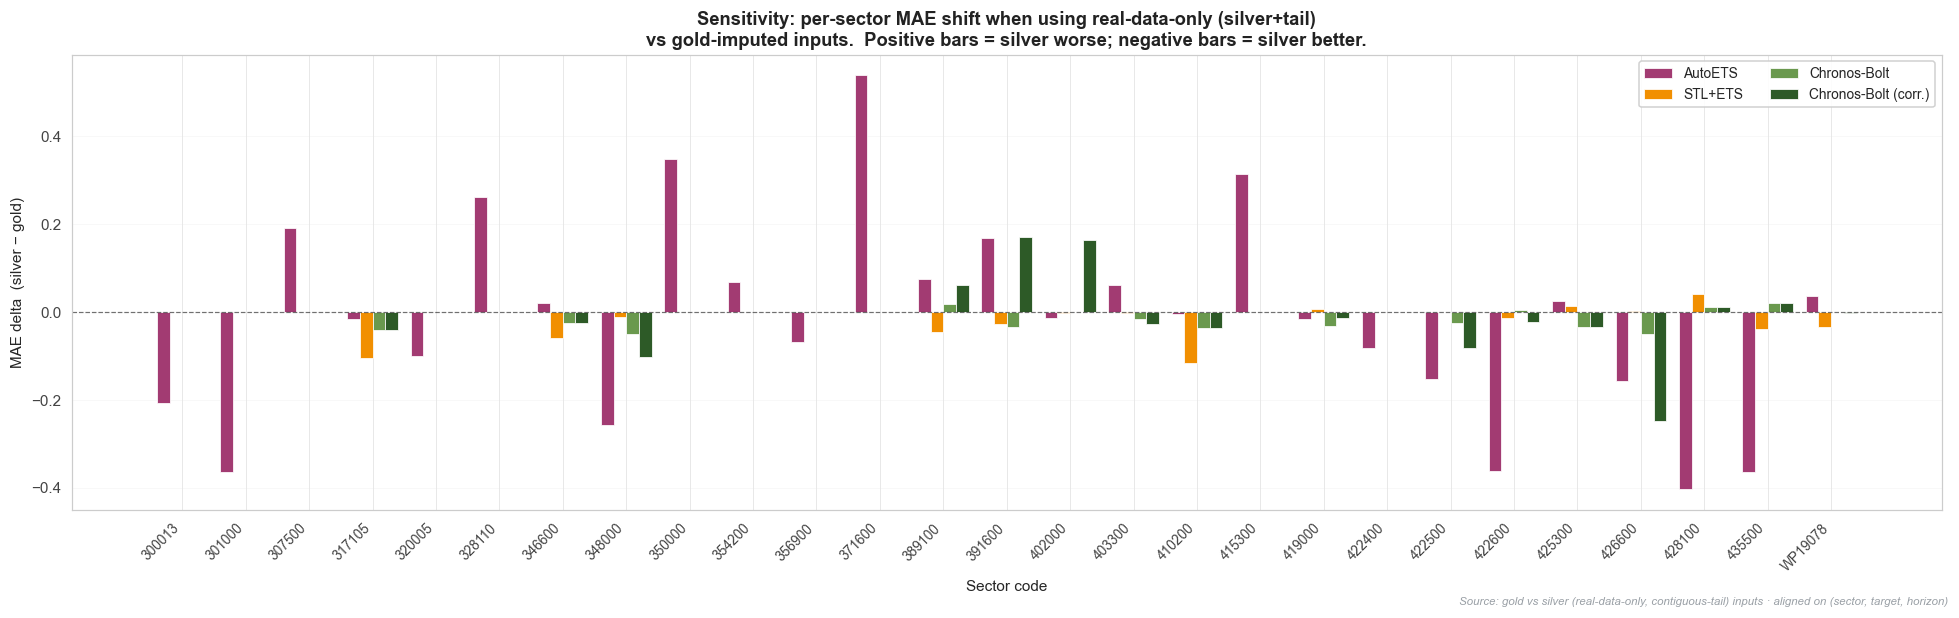

In [23]:
# Per-method aggregates over the affected sectors + delta bar chart.

if sensitivity.empty or affected.empty:
    print("Nothing to plot — no sectors show differing predictions.")
else:
    # Methods present in the sensitivity comparison, in canonical order.
    methods_in_plot = [m for m in METHOD_ORDER if m in affected["method"].unique()]

    agg = (affected.groupby("method")
                   .agg(n_sectors      =("sector_code", "nunique"),
                        mean_mae_gold  =("mae_gold",    "mean"),
                        mean_mae_silver=("mae_silver",  "mean"),
                        mean_delta     =("delta",       "mean"),
                        median_delta   =("delta",       "median"),
                        improved       =("delta",       lambda x: int((x < -EPS).sum())),
                        worsened       =("delta",       lambda x: int((x >  EPS).sum())))
                   .round(3)
                   .loc[methods_in_plot])
    agg.index = [METHOD_LABELS[m] for m in agg.index]

    print("Per-method aggregate over affected sectors:\n")
    print(agg.to_string())

    print("\nReading guide:")
    print("  delta = MAE_silver − MAE_gold (per sector, then averaged)")
    print("  delta < 0 → silver+tail forecasts BETTER  (gold imputation hurt the method)")
    print("  delta > 0 → silver+tail forecasts WORSE   (gold's extra training data helped)")
    print("  improved / worsened columns count sectors crossing the ±EPS threshold")

    # ── Visualization: per-sector delta bars, grouped by method ──
    sectors_in_plot = sorted(affected["sector_code"].unique())
    pivot = (affected.pivot(index="sector_code", columns="method", values="delta")
                     .reindex(sectors_in_plot)[methods_in_plot])

    fig, ax = plt.subplots(figsize=(max(11, 0.55 * len(sectors_in_plot) + 3), 5.6))
    x = np.arange(len(pivot))
    n = len(methods_in_plot)
    w = 0.8 / n

    for i, method in enumerate(methods_in_plot):
        offset = (i - (n - 1) / 2) * w
        ax.bar(x + offset, pivot[method].values, w,
               label=METHOD_LABELS[method],
               color=METHOD_COLORS.get(method, "gray"),
               edgecolor="white", linewidth=0.5)

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.55)
    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=45, ha="right", fontsize=9)
    ax.set_xlabel("Sector code")
    ax.set_ylabel("MAE delta  (silver − gold)")
    ax.set_title("Sensitivity: per-sector MAE shift when using real-data-only "
                 "(silver+tail)\nvs gold-imputed inputs.  "
                 "Positive bars = silver worse; negative bars = silver better.")
    ax.legend(loc="best", framealpha=0.9, ncol=2)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    add_source_note(fig, "Source: gold vs silver (real-data-only, contiguous-tail) "
                         "inputs · aligned on (sector, target, horizon)")
    plt.show()

### How to read the sensitivity results

The visualization shows, for each of the 13 reorganized sectors and each univariate method, the MAE delta between the silver+tail and gold-imputed input regimes.

**Three possible patterns and what they mean for the limitations section:**

- **Consistently negative across methods** (silver beats gold): the gold imputation degrades univariate forecasts on the reorganized sectors.  Report it: *"For the thirteen sectors with 2004-2007 reorganization gaps, the gold-table imputation modestly inflates absolute MAE for the univariate methods (mean shift X.XX percentage points).  The relative ranking of methods is unaffected, but absolute values for these sectors should be interpreted with this in mind."*

- **Near zero across methods** (mean delta < ~0.05 pp, no consistent sign): the data-source choice doesn't materially affect the comparison.  Report it once in the methodology: *"A sensitivity check using silver+contiguous-tail inputs in place of gold-imputed inputs yielded a mean MAE shift of X.XX pp for the thirteen reorganized sectors, confirming that the imputation choice does not drive our conclusions."*

- **Consistently positive across methods** (silver worse than gold): the extra training data from imputation outweighs the borrowed-value artifact.  This is a vote *for* the gold-based primary analysis: *"Gold imputation provides additional training signal that improves univariate forecasts despite the borrowed values; the gold-based comparison is the preferred specification."*

- **Mixed (some methods improve, others worsen)**: report per method.  This is the most interesting finding because it shows different forecasting paradigms react differently to the same imputation — worth a short discussion.

The Pipeline column doesn't appear above because Pipeline always trains on gold (the silver run only re-runs the three CV scripts).  This is by design: Pipeline's multivariate features (`trend_index`, `covid_period`, `post_covid`, regime interactions) shield it from the imputation artifact in a way the univariate methods can't replicate.

## 12. Final Winners Table

This is the consolidated answer to the research question.  For each sector, the table reports the forecasting method with the lowest out-of-sample MAE — but only if it actually **beats the baseline** (`SectorQuarterRollingMean`, the production-deployed quarterly rolling mean).  Sectors where no method beats the baseline fall back to showing the baseline itself.

**Selection rule:**

1. For each sector, find the method with the lowest MAE across the four families (Pipeline, AutoETS, STL+ETS, Chronos-Bolt).
2. If that method's MAE < baseline MAE → that method is the sector's winner.
3. Otherwise → the baseline is the winner; no current method outperforms it for that sector.

**Columns:**

- `sbi_code` — SBI code (used in visuals throughout the notebook)
- `title` — Dutch-language sector description from CBS
- `winning_method` — which method wins for this sector
- `settings` — the specific configuration that won: Pipeline sub-variant (Ridge / ElasticNet / etc.), AutoETS spec, STL+ETS correction variant.  For Chronos-Bolt: "zero-shot" (no per-sector tuning).
- `MAE`, `MASE`, `bias` — the winner's metrics on the out-of-sample window.  When the baseline is the winner only `MAE` is shown.
- `baseline_MAE` — the SectorQuarterRollingMean baseline's MAE on the same window
- `improvement_pct` — `(baseline_MAE − winner_MAE) / baseline_MAE × 100`.  Positive = beats baseline.  Zero (with `winning_method = Baseline`) = no method outperforms.

In [24]:
# Build the final winners table.
# Uses `per_sector` (section 4) for method MAE/MASE/bias, and the baseline MAE
# loaded above.  Selection rule: best method per sector, but only if it beats
# the baseline; otherwise the baseline is shown.

def _settings_for(method_name, sbi_code):
    """Return a short string describing the configuration that won."""
    if method_name == "Pipeline":
        return pipeline_settings.get(sbi_code, "—")

    if method_name == "AutoETS":
        cfg = autoets_settings.get(sbi_code, {})
        if not cfg:
            return "—"
        if isinstance(cfg, dict):
            # autoets_best_configs.json stores the winning ETS spec under
            # "best_model_spec" and the COVID correction under "winning_correction".
            spec = (cfg.get("best_model_spec")
                    or cfg.get("model_spec")
                    or cfg.get("spec") or cfg.get("ets_spec"))
            corr = (cfg.get("winning_correction")
                    or cfg.get("best_correction") or cfg.get("correction"))
            parts = [str(p) for p in (spec, corr)
                     if p and str(p).lower() not in ("none", "no_correction")]
            return " / ".join(parts) if parts else "—"
        return str(cfg)

    if method_name == "STL_ETS":
        cfg = stl_ets_settings.get(sbi_code, "")
        if isinstance(cfg, dict):
            corr = (cfg.get("winning_correction")
                    or cfg.get("best_correction") or cfg.get("correction"))
            return str(corr) if corr and str(corr).lower() != "none" else "—"
        return str(cfg) if cfg else "—"

    if method_name == "Chronos_Bolt":
        return "zero-shot"

    if method_name == "Chronos_Bolt_corrected":
        cfg = chronos_corrected_settings.get(sbi_code, {})
        corr = cfg.get("winning_correction") if isinstance(cfg, dict) else None
        if not corr or str(corr).lower() == "no_correction":
            return "corr: none (zero-shot won)"
        return f"corr: {corr}"

    if method_name == "Baseline":
        return "SectorQuarterRollingMean"
    return "—"


winner_rows = []
for sec, sec_metrics in per_sector.groupby("sector_code"):
    sec = str(sec)
    valid = sec_metrics.dropna(subset=["MAE"])
    if valid.empty:
        continue

    best = valid.loc[valid["MAE"].idxmin()]
    bl_mae = float(baseline_mae.get(sec, np.nan)) if not baseline_mae.empty else np.nan
    has_baseline   = not np.isnan(bl_mae)
    beats_baseline = has_baseline and best["MAE"] < bl_mae

    if beats_baseline or not has_baseline:
        win_method  = best["method"]
        win_mae     = float(best["MAE"])
        win_mase    = float(best["MASE"]) if pd.notna(best["MASE"]) else np.nan
        win_bias    = float(best["bias"])
        improvement = ((bl_mae - best["MAE"]) / bl_mae * 100.0
                       if has_baseline and bl_mae > 0 else np.nan)
    else:
        win_method  = "Baseline"
        win_mae     = bl_mae
        win_mase    = np.nan
        win_bias    = np.nan
        improvement = 0.0

    winner_rows.append({
        "sbi_code":         sec,
        "title":            sbi_titles.get(sec, "—"),
        "winning_method":   METHOD_LABELS.get(win_method, win_method),
        "settings":         _settings_for(win_method, sec),
        "MAE":              round(win_mae,  4),
        "MASE":             round(win_mase, 3) if pd.notna(win_mase) else np.nan,
        "bias":             round(win_bias, 4) if pd.notna(win_bias) else np.nan,
        "baseline_MAE":     round(bl_mae,   4) if has_baseline else np.nan,
        "improvement_pct":  round(improvement, 1) if pd.notna(improvement) else np.nan,
    })

winners_final = (pd.DataFrame(winner_rows)
                   .sort_values(["winning_method", "improvement_pct"],
                                ascending=[True, False], na_position="last")
                   .reset_index(drop=True))

_baseline_label = METHOD_LABELS.get("Baseline", "Baseline")
n_total   = len(winners_final)
n_beat    = (winners_final["winning_method"] != _baseline_label).sum()
n_no_beat = (winners_final["winning_method"] == _baseline_label).sum()

print(f"Sectors evaluated: {n_total}")
if n_total:
    print(f"  Beat the baseline: {n_beat}  ({100*n_beat/n_total:.0f}%)")
    print(f"  No method beats:   {n_no_beat}  ({100*n_no_beat/n_total:.0f}%)")
print()
print("Wins per method:")
for m, c in winners_final["winning_method"].value_counts().items():
    print(f"  {m:<24s} {c:>3d}")

Sectors evaluated: 39
  Beat the baseline: 39  (100%)
  No method beats:   0  (0%)

Wins per method:
  STL+ETS                   18
  AutoETS                   12
  Chronos-Bolt               5
  Chronos-Bolt (corr.)       2
  Pipeline                   2


In [25]:
# Render the final winners table.
# Wide rows for the title column; use pandas styling for visual hierarchy.

# Method -> color (mirrors METHOD_COLORS so the table matches charts elsewhere).
_method_color = {METHOD_LABELS[m]: METHOD_COLORS[m] for m in METHOD_ORDER}
_method_color["Baseline"] = "#999999"  # neutral grey for the baseline-winner rows

def _color_winning_method(val):
    bg = _method_color.get(val, "#ffffff")
    return f"background-color: {bg}; color: white; font-weight: bold;"

def _color_improvement(val):
    # Diverging colormap: positive = green, zero/negative = grey
    if pd.isna(val):
        return ""
    if val <= 0:
        return "color: #999999;"
    # Scale brightness with improvement magnitude (clipped at 30 pp)
    intensity = min(val / 30.0, 1.0)
    g = int(120 + 100 * intensity)
    return f"color: rgb(0, {g}, 60); font-weight: bold;"

styled = (winners_final.style
            .applymap(_color_winning_method, subset=["winning_method"])
            .applymap(_color_improvement,    subset=["improvement_pct"])
            .format({
                "MAE":             "{:.4f}",
                "MASE":            "{:.3f}",
                "bias":            "{:+.4f}",
                "baseline_MAE":    "{:.4f}",
                "improvement_pct": "{:+.1f}%",
            }, na_rep="—")
            .set_properties(subset=["title"], **{"max-width": "350px", "white-space": "normal"})
            .set_properties(subset=["sbi_code"], **{"font-family": "monospace"})
            .set_caption("Final Winners — best method per sector that beats the baseline (sorted by method, then improvement)"))

styled

,sbi_code,title,winning_method,settings,MAE,MASE,bias,baseline_MAE,improvement_pct
0,417400,O Openbaar bestuur en overheidsdiensten,AutoETS,MNM / no_correction|winsorized,0.1586,0.214,-0.0717,0.7417,+78.6%
1,391600,J Informatie en communicatie,AutoETS,MNA / no_correction|winsorized,0.1480,0.333,+0.0346,0.4444,+66.7%
2,356900,46 Groothandel en handelsbemiddeling,AutoETS,MAdM / seasonal_mean|b3,0.1225,0.374,-0.0397,0.3278,+62.6%
3,371600,47 Detailhandel (niet in auto's),AutoETS,MAM / no_correction|winsorized,0.1178,0.382,-0.0045,0.3083,+61.8%
4,354300,45 Autohandel en -reparatie,AutoETS,MNM / no_correction|winsorized,0.2167,0.446,+0.0738,0.4861,+55.4%
5,415300,812 Schoonmaakbedrijven,AutoETS,MAdM,0.2552,0.476,+0.0281,0.5361,+52.4%
6,410200,N Verhuur en overige zakelijke diensten,AutoETS,MAdN,0.1998,0.507,+0.0377,0.3944,+49.3%
7,354200,G Handel,AutoETS,MNM / seasonal_mean|b2,0.1507,0.548,-0.0361,0.2750,+45.2%
8,320005,19-22 Raffinaderijen en chemie,AutoETS,MNM / seasonal_mean|b2,0.2252,0.563,-0.0605,0.4000,+43.7%
9,402000,L Verhuur en handel van onroerend goed,AutoETS,MNA / no_correction|winsorized,0.2661,0.570,-0.0383,0.4667,+43.0%


### Reading the winners table

Three patterns to look for:

1. **Sectors with high `improvement_pct` (say > 20%)** — these are wins that justify deploying the method.  The simpler the winning method (Chronos zero-shot, AutoETS with a standard spec), the more attractive: less engineering risk for the operational benefit.

2. **Sectors where the baseline is the winner** — these are not failures of the methods, but signals about the sectors: the quarterly rolling mean is hard to beat for series that are essentially flat or that have very low signal-to-noise at the four-quarter horizon.  Worth investigating whether more aggregated SBI categories show clearer patterns.

3. **Mixed winners across the four method families** — if no single method dominates, the operational answer is *"deploy a per-sector router"* (each sector gets its own winning method), not *"deploy one method everywhere"*.  The `settings` column gives the recipe.

The `MASE` and `bias` columns are populated only when a method (not the baseline) is the winner.  The baseline's MASE would by construction be close to 1.0 (it's a rolling-mean baseline, which is itself a smoothing-naive variant), so reporting it would be misleading.

## 13. Summary

The comparison gives you several distinct findings for the report:

**Overall performance** (Section 3): the three-metric table — MAE for absolute error, MASE for "beats the operational baseline", bias for systematic miscalibration. Lead with MASE in cross-sector claims because it's the only metric that's fair across sectors of different baseline difficulty.

**Where each method shines** (Sections 5–6): the per-sector heatmap and win count tell the story. If one method dominates by a wide margin, recommend it. If wins are split, the cross-method selection itself is your contribution.

**Paradigm question** (Section 7): the quadrant tells you whether the data needs sophisticated models. A bottom-right cluster (multivariate + explainable) means your features earned their keep. A bottom-left cluster means simple methods sufficed; a top-left cluster means the foundation-model priors beat the engineered features.

**Forecast horizon trade-off** (Section 8): if a method beats the baselines at h=1 but loses at h=4, that matters — the business owner makes decisions for the year ahead.

**Regime robustness** (Section 9): post-2023 results are the most decision-relevant. The method that holds up there is the one to deploy.

**Statistical claims** (Section 10): use these sparingly — only make a "statistically significant" claim where Friedman + DM agree. Otherwise report differences as descriptive observations. Note that the two Chronos forms are closely related (same model, with/without correction), so expect them to sit near each other in the rank diagram.

**Input-data sensitivity** (Section 11): for sectors with reorganization gaps, gold imputation borrows from sibling sectors. The silver-vs-gold delta shows whether that helped or hurt each method — relevant to whether the deployed pipeline should impute at all.

### The two Chronos forms

Read them together: **zero-shot Chronos-Bolt** is the honest "out of the box" result, while **Chronos-Bolt (corr.)** is the fair head-to-head against AutoETS/STL+ETS, since all three then receive the same per-sector COVID-correction selection (chosen on inner folds, applied to context only). If the corrected form gains little over zero-shot, the foundation model is already robust to the COVID structural break; if it gains a lot, the break was hurting the untuned model.

### Honest caveats to put in the report

- Per-sector winner selection uses each method's own protocol — comparable in spirit but not identical (Pipeline uses outer folds; the univariate methods select a correction on inner CV).
- MASE here is anchored to the **`SectorQuarterRollingMean` operational baseline**, with the baseline MAE measured on the identical aligned `(sector, target_date, horizon)` points (not a textbook in-sample naive). MASE < 1 therefore means "beats the deployed baseline". Strictly this is a relative MAE against an operational baseline; flag the choice in the methods section. Any aligned sector lacking baseline predictions is reported and excluded from MASE rather than silently mixed with a different denominator. The per-row baseline is read directly from `model_predictions` (the deployed model's own outer-fold walk-forward predictions, stored under `SectorQuarterRollingMean_<sector>`); section 3 reconciles those rows against the stored aggregate MAE with an explicit PASS/FAIL, so the denominator is provably the deployed model's — no reconstruction or estimator assumptions.
- Prediction intervals are only available from Chronos (80% from quantiles q10/q90; the 95% band is intentionally left empty since the model was not trained on those quantiles); the other methods don't quantify uncertainty here.
- 4-quarter-ahead error is necessarily larger than 1-quarter; the appropriate baseline is "what does UWV currently use?" not "what's theoretically possible?"
- The baseline denominator is computed on the aligned test targets, so it shares whatever target definition the methods are scored on — it is a relative yardstick (vs. the operational model), not an absolute floor. Because the same baseline also gates the winners table, "beats the baseline" there and "MASE < 1" here are the same condition.